In [ ]:
# ============================
# Cell 1: Google Drive 마운트 및 데이터 로드/전처리
# ============================
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from google.colab import drive
from google.colab import files
# import io # 파일 경로 직접 사용 시 필요 없음

# --- Google Drive 마운트 ---
try:
    drive.mount('/content/drive')
    print("Google Drive 마운트 성공.")
    # !!! 중요: Google Drive 내 실제 파일 경로로 수정하세요 !!!
    # 예: 내 드라이브 최상위에 파일이 있다면 '/content/drive/MyDrive/all_results.csv'
    # 예: 'Colab Notebooks' 폴더 안에 있다면 '/content/drive/MyDrive/Colab Notebooks/all_results.csv'
    file_path = 'all_results.csv' # <--- 이 경로를 자신의 파일 경로에 맞게 수정하세요!
except Exception as e:
    print(f"Google Drive 마운트 실패: {e}")
    file_path = None


# --- 설정 ---
COLUMNS_PER_BLOCK = 5 # 각 알고리즘 블록의 데이터 열 개수
SEPARATOR_COLUMNS = 1 # 블록 사이의 빈 열 개수 (CSV상으로는 1개의 빈 열)
base_column_names = ['Algorithm', 'InputType', 'DataSize', 'AverageTime(ms)', 'AverageMemory(MB)']

# --- 데이터 로드 및 전처리 함수 (파일 경로 입력 방식) ---
def load_and_clean_data_from_drive(csv_file_path):
    if csv_file_path is None:
        print("파일 경로가 설정되지 않았습니다.")
        return None
    try:
        # 로컬 파일 경로(마운트된 드라이브)에서 CSV 읽기
        raw_data = pd.read_csv(csv_file_path, header=0, on_bad_lines='skip') # skip으로 잘못된 줄 건너뛰기

        total_columns = len(raw_data.columns)
        # 'Algorithm'으로 시작하는 열 인덱스 찾기
        potential_starts = [i for i, col in enumerate(raw_data.columns) if isinstance(col, str) and 'Algorithm' in col]

        if not potential_starts: # Algorithm 열을 찾지 못하면 기본 블록 구조로 시도
             potential_starts = range(0, total_columns, COLUMNS_PER_BLOCK + SEPARATOR_COLUMNS)

        all_blocks_data = []
        for start_col_index in potential_starts:
            end_col_index = start_col_index + COLUMNS_PER_BLOCK
            if start_col_index < total_columns:
                # 실제 존재하는 열까지만 슬라이싱
                current_block_cols = raw_data.iloc[:, start_col_index:min(end_col_index, total_columns)]
                # 열 개수가 정확히 맞는지 확인
                if len(current_block_cols.columns) == COLUMNS_PER_BLOCK:
                    # 열 이름을 표준 이름으로 변경
                    current_block_cols.columns = base_column_names
                    all_blocks_data.append(current_block_cols)

        if not all_blocks_data:
            raise ValueError("CSV 파일에서 유효한 데이터 블록을 찾을 수 없습니다. 파일 구조를 확인하세요.")

        combined_data = pd.concat(all_blocks_data, ignore_index=True)

        # --- 데이터 클리닝 ---
        combined_data = combined_data.dropna(subset=['Algorithm'], how='all') # Algorithm 열이 완전히 비거나 NaN인 행 제거
        combined_data['Algorithm'] = combined_data['Algorithm'].astype(str).str.strip()
        combined_data = combined_data[combined_data['Algorithm'] != 'Algorithm'] # 헤더 행 제거

        def convert_datasize_eval(size):
            if isinstance(size, str):
                try:
                    return pd.eval(size.lower().strip().replace('k', '*1e3').replace('m', '*1e6'))
                except: return np.nan
            elif isinstance(size, (int, float)): return size
            else: return np.nan

        combined_data['DataSize'] = combined_data['DataSize'].apply(convert_datasize_eval)
        combined_data['AverageTime(ms)'] = pd.to_numeric(combined_data['AverageTime(ms)'], errors='coerce')
        combined_data['AverageMemory(MB)'] = pd.to_numeric(combined_data['AverageMemory(MB)'], errors='coerce')
        combined_data = combined_data.dropna(subset=base_column_names) # 필수 열에 NaN 있으면 제거
        combined_data['DataSize'] = combined_data['DataSize'].astype(int)
        combined_data['InputType'] = combined_data['InputType'].astype(str).str.strip()

        print(f"데이터 로드 및 전처리 완료. 총 {len(combined_data)}개의 유효 데이터 행.")
        print("감지된 InputType:", combined_data['InputType'].unique())
        return combined_data

    except FileNotFoundError:
        print(f"오류: 파일 '{csv_file_path}'을(를) 찾을 수 없습니다. 경로를 확인하세요.")
        return None
    except ValueError as e:
        print(f"데이터 처리 중 오류: {e}")
        return None
    except Exception as e:
        print(f"코드 실행 중 예상치 못한 오류가 발생했습니다: {e}")
        return None

# --- 데이터 로드 실행 (파일 경로 사용) ---
# 위에서 정의된 file_path 변수 사용
cleaned_data = load_and_clean_data_from_drive(file_path)

# --- 스타일 설정 및 변수 준비 (모든 그래프 공통) ---
plt.style.use('seaborn-v0_8-whitegrid')
if cleaned_data is not None:
    algorithms = sorted(cleaned_data['Algorithm'].unique())
    color_map = plt.cm.get_cmap('tab20', len(algorithms))
    algo_colors = {algo: color_map(i) for i, algo in enumerate(algorithms)}
else:
    algorithms = []
    algo_colors = {}

# 데이터 확인 (선택 사항)
if cleaned_data is not None:
    print("\n처리된 데이터 샘플:")
    print(cleaned_data.head())


Mounted at /content/drive
Google Drive 마운트 성공.
데이터 로드 및 전처리 완료. 총 192개의 유효 데이터 행.
감지된 InputType: ['ascending' 'descending' 'random' 'part-random']

처리된 데이터 샘플:
     Algorithm    InputType  DataSize  AverageTime(ms)  AverageMemory(MB)
0  bubble_sort    ascending      1000             0.97               7.27
1  bubble_sort   descending      1000             4.92               7.05
2  bubble_sort       random      1000             3.59               7.41
3  bubble_sort  part-random      1000             3.16               7.20
4  bubble_sort    ascending     10000           101.58               7.29


<ipython-input-1-6d84316cd7f7>:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', len(algorithms))


메모리 그래프 저장 완료: all_algorithms_memory_plot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: all_algorithms_memory_plot.png


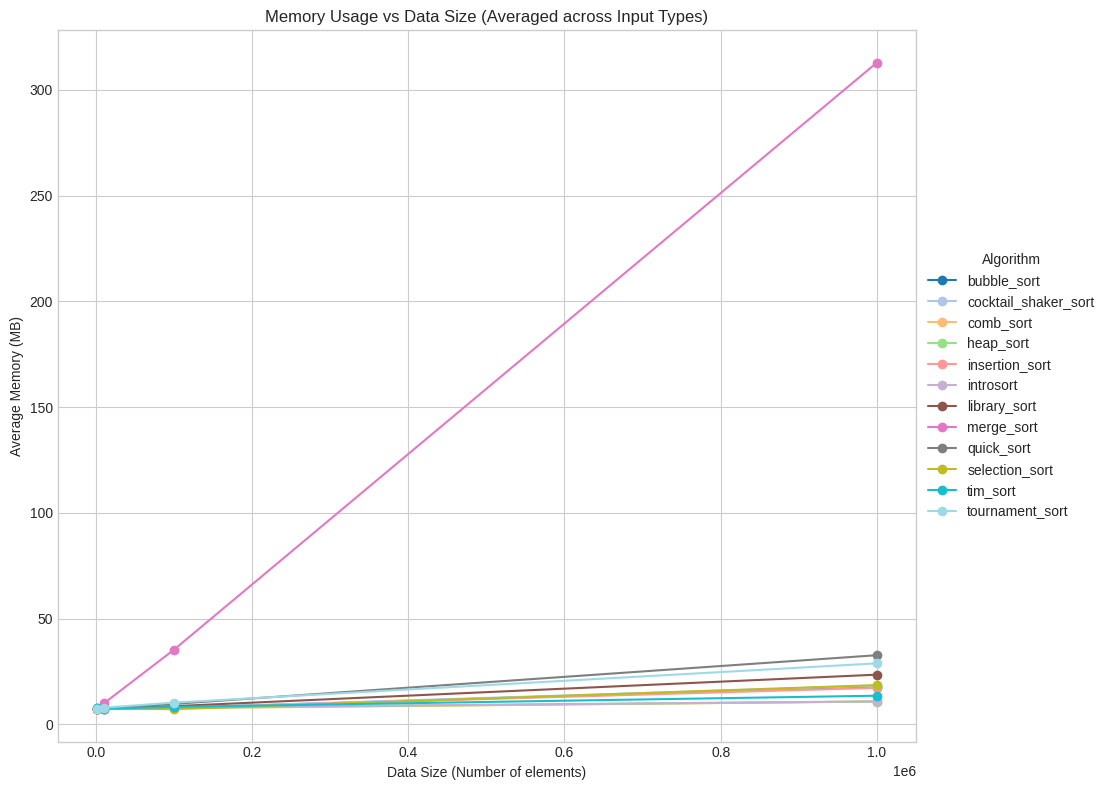

In [ ]:
# ============================
# Cell 2: 메모리 그래프 + 저장 및 다운로드
# ============================

# 필요한 라이브러리 임포트 확인 (pandas, matplotlib.pyplot, numpy 등)
# 다운로드를 위해 files 모듈 임포트
from google.colab import files
import matplotlib.pyplot as plt # plt 사용 위해 필요
import pandas as pd # 다른 필요한 import도 확인

# 저장할 파일 이름 정의
output_memory_filename = "all_algorithms_memory_plot.png"

# cleaned_data 와 algorithms, algo_colors 가 이전 셀에서 정의되었는지 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    try:
        # --- 그래프 생성 시작 ---
        # Figure와 Axes 객체 얻기
        fig, ax = plt.subplots(figsize=(14, 8))

        # 메모리 데이터 집계
        average_memory = cleaned_data.groupby(['Algorithm', 'DataSize'])['AverageMemory(MB)'].mean().reset_index()

        # 각 알고리즘 플로팅
        for algo in algorithms: # 정렬된 알고리즘 순서 사용 (이전 셀에서 정의됨 가정)
            subset = average_memory[average_memory['Algorithm'] == algo].sort_values('DataSize')
            if not subset.empty:
                ax.plot(subset['DataSize'], subset['AverageMemory(MB)'], marker='o', linestyle='-', label=algo, color=algo_colors.get(algo))

        # 그래프 속성 설정 (ax 사용)
        ax.set_xlabel('Data Size (Number of elements)')
        ax.set_ylabel('Average Memory (MB)')
        ax.set_title('Memory Usage vs Data Size (Averaged across Input Types)')
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        ax.legend(title='Algorithm', loc='center left', bbox_to_anchor=(1, 0.5))
        fig.tight_layout(rect=[0, 0, 0.80, 1]) # 범례 공간 확보
        ax.grid(True)

        # --- 파일 저장 및 다운로드 (show 전에 실행) ---
        # 1. 파일 저장
        fig.savefig(output_memory_filename, bbox_inches='tight', dpi=300, transparent=True)
        print(f"메모리 그래프 저장 완료: {output_memory_filename}")

        # 2. 파일 다운로드
        files.download(output_memory_filename)
        print(f"파일 다운로드 시작: {output_memory_filename}")

        # --- 화면에 그래프 표시 ---
        plt.show() # 저장 및 다운로드 후 그래프 표시

    except Exception as e:
        print(f"메모리 그래프 생성 또는 저장/다운로드 중 오류 발생: {e}")
        # 오류 발생 시 생성 중인 figure 닫기 (선택적)
        if 'fig' in locals():
            plt.close(fig)

else:
    print("오류: 메모리 그래프 생성에 필요한 데이터(cleaned_data, algorithms, algo_colors)가 준비되지 않았습니다. 이전 셀들을 먼저 실행해주세요.")



'ascending' 시간 그래프 저장 완료: time_plot_ascending.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: time_plot_ascending.png


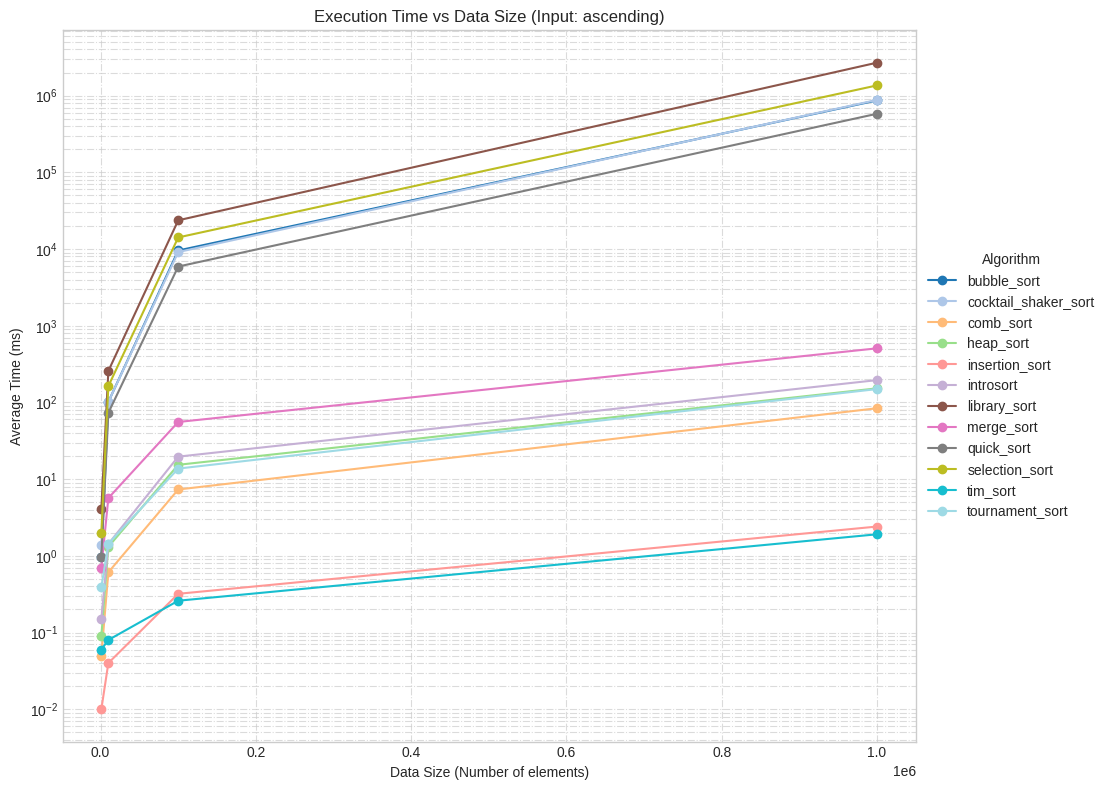

In [ ]:
# ============================
# Cell 3: 시간 그래프 (Input: ascending) + 저장 및 다운로드
# ============================

# 필요한 라이브러리 임포트 확인
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 저장할 파일 이름 정의
output_time_ascending_filename = "time_plot_ascending.png"

# cleaned_data, algorithms, algo_colors 가 이전 셀에서 정의되었는지 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    input_type_filter = 'ascending'
    # 지정된 InputType으로 데이터 필터링
    time_data_filtered = cleaned_data[cleaned_data['InputType'] == input_type_filter]

    if not time_data_filtered.empty:
        try:
            # --- 그래프 생성 시작 ---
            fig, ax = plt.subplots(figsize=(14, 8))

            # 각 알고리즘 플로팅
            for algo in algorithms: # 정렬된 알고리즘 순서 사용
                subset = time_data_filtered[time_data_filtered['Algorithm'] == algo].sort_values('DataSize')
                if not subset.empty:
                    ax.plot(subset['DataSize'], subset['AverageTime(ms)'], marker='o', linestyle='-', label=algo, color=algo_colors.get(algo))

            # 그래프 속성 설정 (ax 사용)
            ax.set_xlabel('Data Size (Number of elements)')
            ax.set_ylabel('Average Time (ms)')
            ax.set_title(f'Execution Time vs Data Size (Input: {input_type_filter})')
            ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
            ax.set_yscale('log') # 시간 차이가 크므로 Y축 로그 스케일 적용
            ax.legend(title='Algorithm', loc='center left', bbox_to_anchor=(1, 0.5))
            fig.tight_layout(rect=[0, 0, 0.80, 1])
            ax.grid(True, which="both", ls="-.", alpha=0.7) # 로그 스케일용 그리드

            # --- 파일 저장 및 다운로드 (show 전에 실행) ---
            # 1. 파일 저장
            fig.savefig(output_time_ascending_filename, bbox_inches='tight', dpi=300, transparent=True)
            print(f"'{input_type_filter}' 시간 그래프 저장 완료: {output_time_ascending_filename}")

            # 2. 파일 다운로드
            files.download(output_time_ascending_filename)
            print(f"파일 다운로드 시작: {output_time_ascending_filename}")

            # --- 화면에 그래프 표시 ---
            plt.show() # 저장 및 다운로드 후 그래프 표시

        except Exception as e:
            print(f"'{input_type_filter}' 시간 그래프 생성 또는 저장/다운로드 중 오류 발생: {e}")
            if 'fig' in locals():
                plt.close(fig) # 오류 시 figure 닫기

    else:
        print(f"'{input_type_filter}' 타입에 대한 데이터가 없어 시간 그래프를 생성할 수 없습니다.")
else:
    print("오류: 시간 그래프 생성에 필요한 데이터(cleaned_data, algorithms, algo_colors)가 준비되지 않았습니다. 이전 셀들을 먼저 실행해주세요.")



'descending' 시간 그래프 저장 완료: time_plot_descending.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: time_plot_descending.png


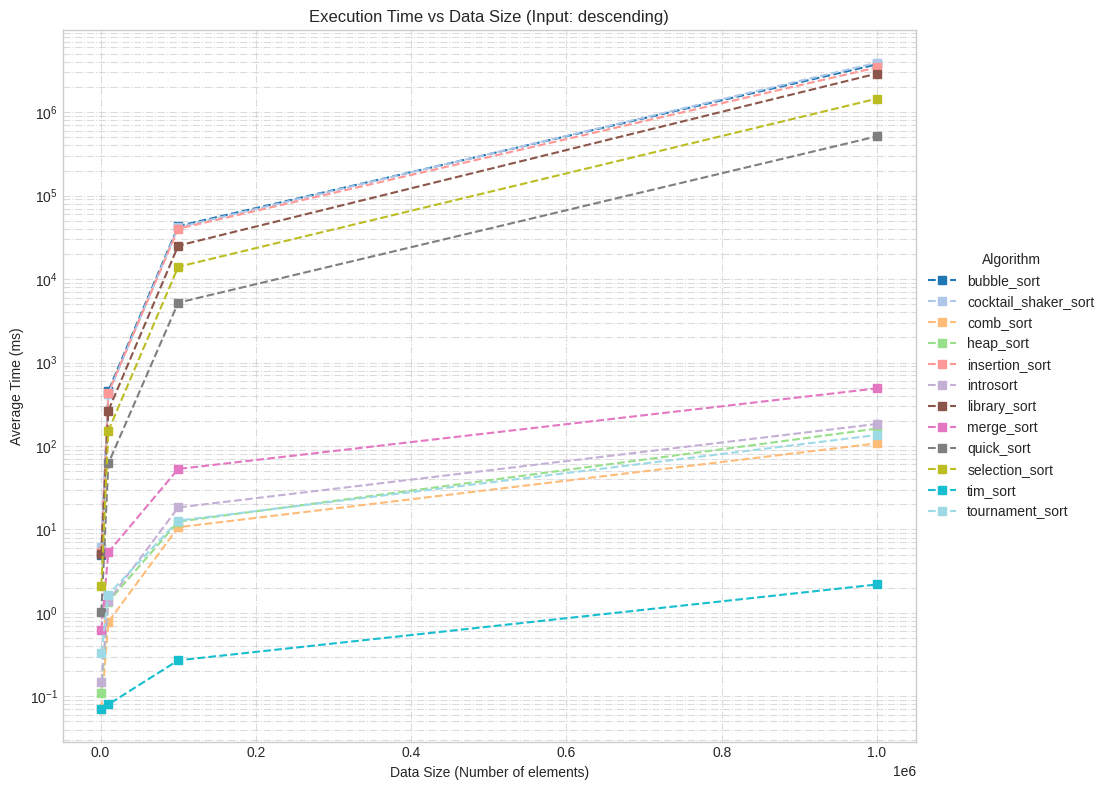

In [ ]:
# ============================
# Cell 4: 시간 그래프 (Input: descending) + 저장 및 다운로드
# ============================

# 필요한 라이브러리 임포트 확인
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 저장할 파일 이름 정의
output_time_descending_filename = "time_plot_descending.png"

# cleaned_data, algorithms, algo_colors 가 이전 셀에서 정의되었는지 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    input_type_filter = 'descending'
    # 지정된 InputType으로 데이터 필터링
    time_data_filtered = cleaned_data[cleaned_data['InputType'] == input_type_filter]

    if not time_data_filtered.empty:
        try:
            # --- 그래프 생성 시작 ---
            fig, ax = plt.subplots(figsize=(14, 8))

            # 각 알고리즘 플로팅
            for algo in algorithms:
                subset = time_data_filtered[time_data_filtered['Algorithm'] == algo].sort_values('DataSize')
                if not subset.empty:
                    # 마커와 라인 스타일 변경 (기존 코드 유지)
                    ax.plot(subset['DataSize'], subset['AverageTime(ms)'], marker='s', linestyle='--', label=algo, color=algo_colors.get(algo))

            # 그래프 속성 설정 (ax 사용)
            ax.set_xlabel('Data Size (Number of elements)')
            ax.set_ylabel('Average Time (ms)')
            ax.set_title(f'Execution Time vs Data Size (Input: {input_type_filter})')
            ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
            ax.set_yscale('log')
            ax.legend(title='Algorithm', loc='center left', bbox_to_anchor=(1, 0.5))
            fig.tight_layout(rect=[0, 0, 0.80, 1])
            ax.grid(True, which="both", ls="-.", alpha=0.7)

            # --- 파일 저장 및 다운로드 (show 전에 실행) ---
            # 1. 파일 저장
            fig.savefig(output_time_descending_filename, bbox_inches='tight', dpi=300, transparent=True)
            print(f"'{input_type_filter}' 시간 그래프 저장 완료: {output_time_descending_filename}")

            # 2. 파일 다운로드
            files.download(output_time_descending_filename)
            print(f"파일 다운로드 시작: {output_time_descending_filename}")

            # --- 화면에 그래프 표시 ---
            plt.show() # 저장 및 다운로드 후 그래프 표시

        except Exception as e:
            print(f"'{input_type_filter}' 시간 그래프 생성 또는 저장/다운로드 중 오류 발생: {e}")
            if 'fig' in locals():
                plt.close(fig) # 오류 시 figure 닫기

    else:
        print(f"'{input_type_filter}' 타입에 대한 데이터가 없어 시간 그래프를 생성할 수 없습니다.")
else:
    print("오류: 시간 그래프 생성에 필요한 데이터(cleaned_data, algorithms, algo_colors)가 준비되지 않았습니다. 이전 셀들을 먼저 실행해주세요.")



'random' 시간 그래프 저장 완료: time_plot_random.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: time_plot_random.png


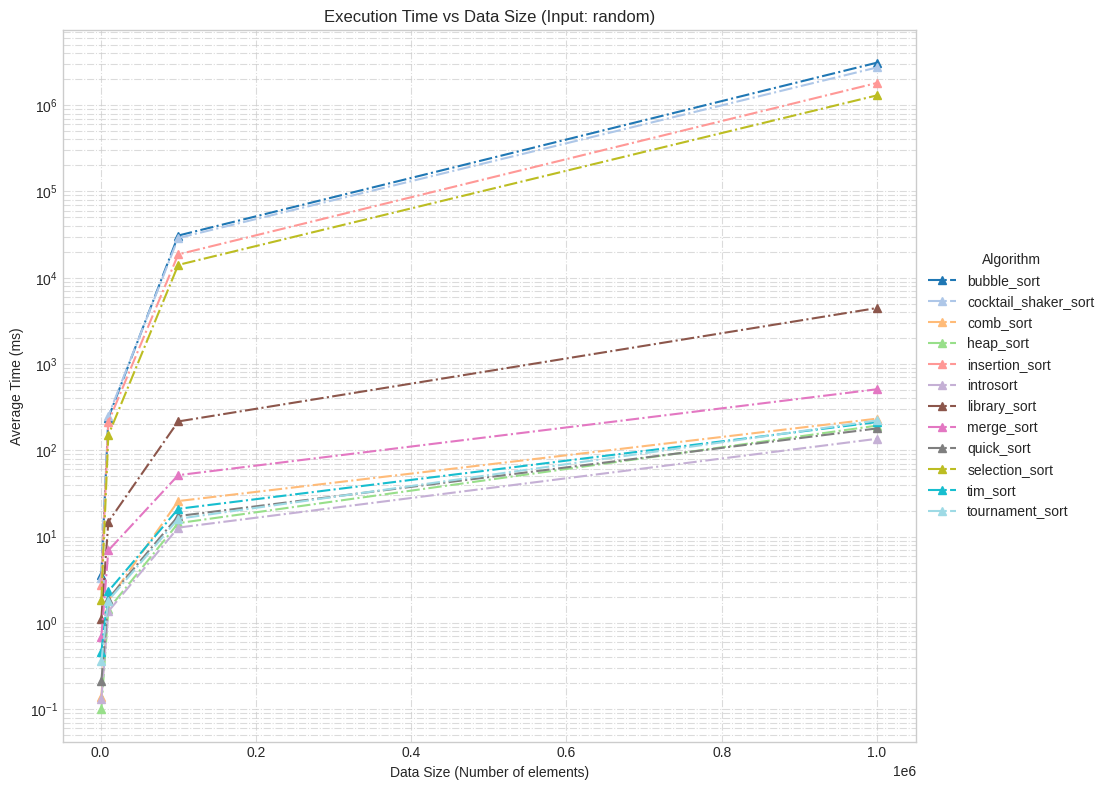

In [ ]:
# ============================
# Cell 5: 시간 그래프 (Input: random) + 저장 및 다운로드
# ============================

# 필요한 라이브러리 임포트 확인
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 저장할 파일 이름 정의
output_time_random_filename = "time_plot_random.png"

# cleaned_data, algorithms, algo_colors 가 이전 셀에서 정의되었는지 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    input_type_filter = 'random'
    # 지정된 InputType으로 데이터 필터링
    time_data_filtered = cleaned_data[cleaned_data['InputType'] == input_type_filter]

    if not time_data_filtered.empty:
        try:
            # --- 그래프 생성 시작 ---
            fig, ax = plt.subplots(figsize=(14, 8))

            # 각 알고리즘 플로팅
            for algo in algorithms:
                subset = time_data_filtered[time_data_filtered['Algorithm'] == algo].sort_values('DataSize')
                if not subset.empty:
                    # 마커와 라인 스타일 변경 (기존 코드 유지)
                    ax.plot(subset['DataSize'], subset['AverageTime(ms)'], marker='^', linestyle='-.', label=algo, color=algo_colors.get(algo))

            # 그래프 속성 설정 (ax 사용)
            ax.set_xlabel('Data Size (Number of elements)')
            ax.set_ylabel('Average Time (ms)')
            ax.set_title(f'Execution Time vs Data Size (Input: {input_type_filter})')
            ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
            ax.set_yscale('log')
            ax.legend(title='Algorithm', loc='center left', bbox_to_anchor=(1, 0.5))
            fig.tight_layout(rect=[0, 0, 0.80, 1])
            ax.grid(True, which="both", ls="-.", alpha=0.7)

            # --- 파일 저장 및 다운로드 (show 전에 실행) ---
            # 1. 파일 저장
            fig.savefig(output_time_random_filename, bbox_inches='tight', dpi=300, transparent=True)
            print(f"'{input_type_filter}' 시간 그래프 저장 완료: {output_time_random_filename}")

            # 2. 파일 다운로드
            files.download(output_time_random_filename)
            print(f"파일 다운로드 시작: {output_time_random_filename}")

            # --- 화면에 그래프 표시 ---
            plt.show() # 저장 및 다운로드 후 그래프 표시

        except Exception as e:
            print(f"'{input_type_filter}' 시간 그래프 생성 또는 저장/다운로드 중 오류 발생: {e}")
            if 'fig' in locals():
                plt.close(fig) # 오류 시 figure 닫기

    else:
        print(f"'{input_type_filter}' 타입에 대한 데이터가 없어 시간 그래프를 생성할 수 없습니다.")
else:
    print("오류: 시간 그래프 생성에 필요한 데이터(cleaned_data, algorithms, algo_colors)가 준비되지 않았습니다. 이전 셀들을 먼저 실행해주세요.")



'part-random' 시간 그래프 저장 완료: time_plot_part_random.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: time_plot_part_random.png


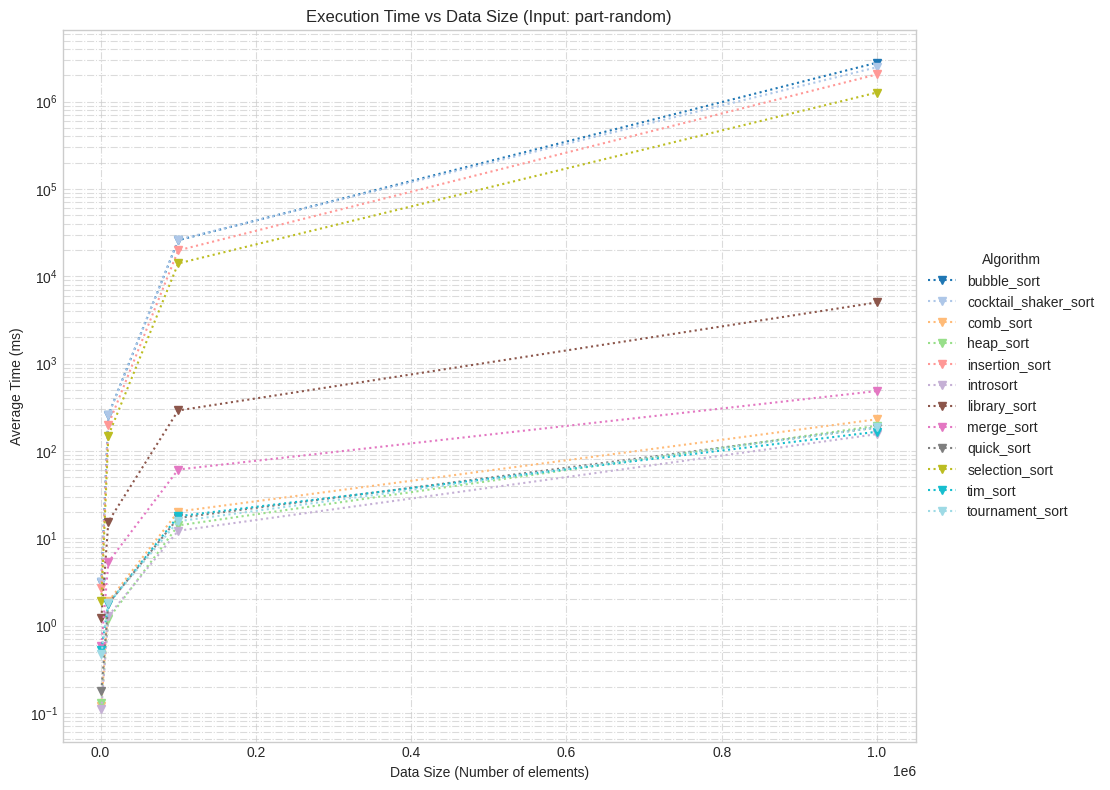

In [ ]:
# ============================
# Cell 6: 시간 그래프 (Input: part-random) + 저장 및 다운로드
# ============================

# 필요한 라이브러리 임포트 확인
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 저장할 파일 이름 정의
output_time_part_random_filename = "time_plot_part_random.png"

# cleaned_data, algorithms, algo_colors 가 이전 셀에서 정의되었는지 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    input_type_filter = 'part-random'
    # 지정된 InputType으로 데이터 필터링
    time_data_filtered = cleaned_data[cleaned_data['InputType'] == input_type_filter]

    if not time_data_filtered.empty:
        try:
            # --- 그래프 생성 시작 ---
            fig, ax = plt.subplots(figsize=(14, 8))

            # 각 알고리즘 플로팅
            for algo in algorithms:
                subset = time_data_filtered[time_data_filtered['Algorithm'] == algo].sort_values('DataSize')
                if not subset.empty:
                    # 마커와 라인 스타일 변경 (기존 코드 유지)
                    ax.plot(subset['DataSize'], subset['AverageTime(ms)'], marker='v', linestyle=':', label=algo, color=algo_colors.get(algo))

            # 그래프 속성 설정 (ax 사용)
            ax.set_xlabel('Data Size (Number of elements)')
            ax.set_ylabel('Average Time (ms)')
            ax.set_title(f'Execution Time vs Data Size (Input: {input_type_filter})')
            ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
            ax.set_yscale('log')
            ax.legend(title='Algorithm', loc='center left', bbox_to_anchor=(1, 0.5))
            fig.tight_layout(rect=[0, 0, 0.80, 1])
            ax.grid(True, which="both", ls="-.", alpha=0.7)

            # --- 파일 저장 및 다운로드 (show 전에 실행) ---
            # 1. 파일 저장
            fig.savefig(output_time_part_random_filename, bbox_inches='tight', dpi=300, transparent=True)
            print(f"'{input_type_filter}' 시간 그래프 저장 완료: {output_time_part_random_filename}")

            # 2. 파일 다운로드
            files.download(output_time_part_random_filename)
            print(f"파일 다운로드 시작: {output_time_part_random_filename}")

            # --- 화면에 그래프 표시 ---
            plt.show() # 저장 및 다운로드 후 그래프 표시

        except Exception as e:
            print(f"'{input_type_filter}' 시간 그래프 생성 또는 저장/다운로드 중 오류 발생: {e}")
            if 'fig' in locals():
                plt.close(fig) # 오류 시 figure 닫기

    else:
        print(f"'{input_type_filter}' 타입에 대한 데이터가 없어 시간 그래프를 생성할 수 없습니다.")
else:
    print("오류: 시간 그래프 생성에 필요한 데이터(cleaned_data, algorithms, algo_colors)가 준비되지 않았습니다. 이전 셀들을 먼저 실행해주세요.")



그래프 생성 함수 'plot_detailed_time_group' (저장/다운로드 기능 포함) 정의 완료.

--- 상세 그룹별 시간 성능 그래프 생성 및 저장/다운로드 시작 ---

 plotting and saving 'Group 1 (Fastest: N log N Opt.)' to 'time_plot_group_1_fastest_n_log_n_opt.png'...
그래프 저장 완료: time_plot_group_1_fastest_n_log_n_opt.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: time_plot_group_1_fastest_n_log_n_opt.png


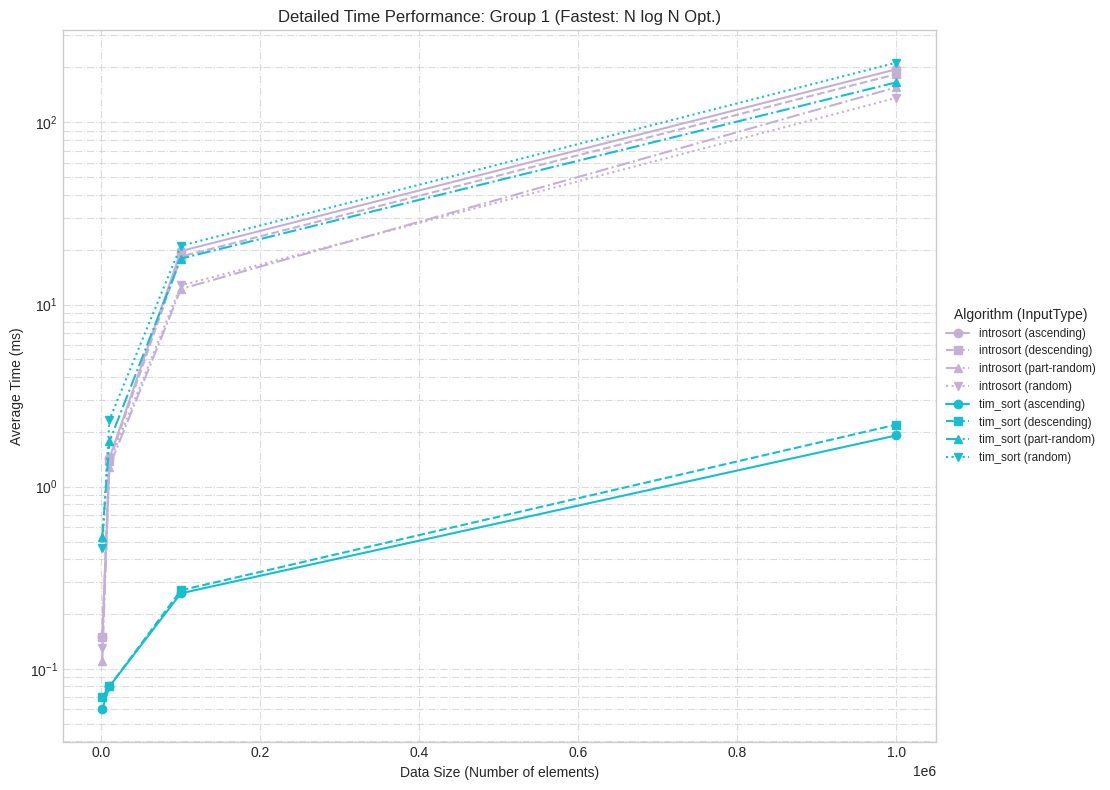


 plotting and saving 'Group 2 (Fast: N log N Gen.)' to 'time_plot_group_2_fast_n_log_n_gen.png'...
그래프 저장 완료: time_plot_group_2_fast_n_log_n_gen.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: time_plot_group_2_fast_n_log_n_gen.png


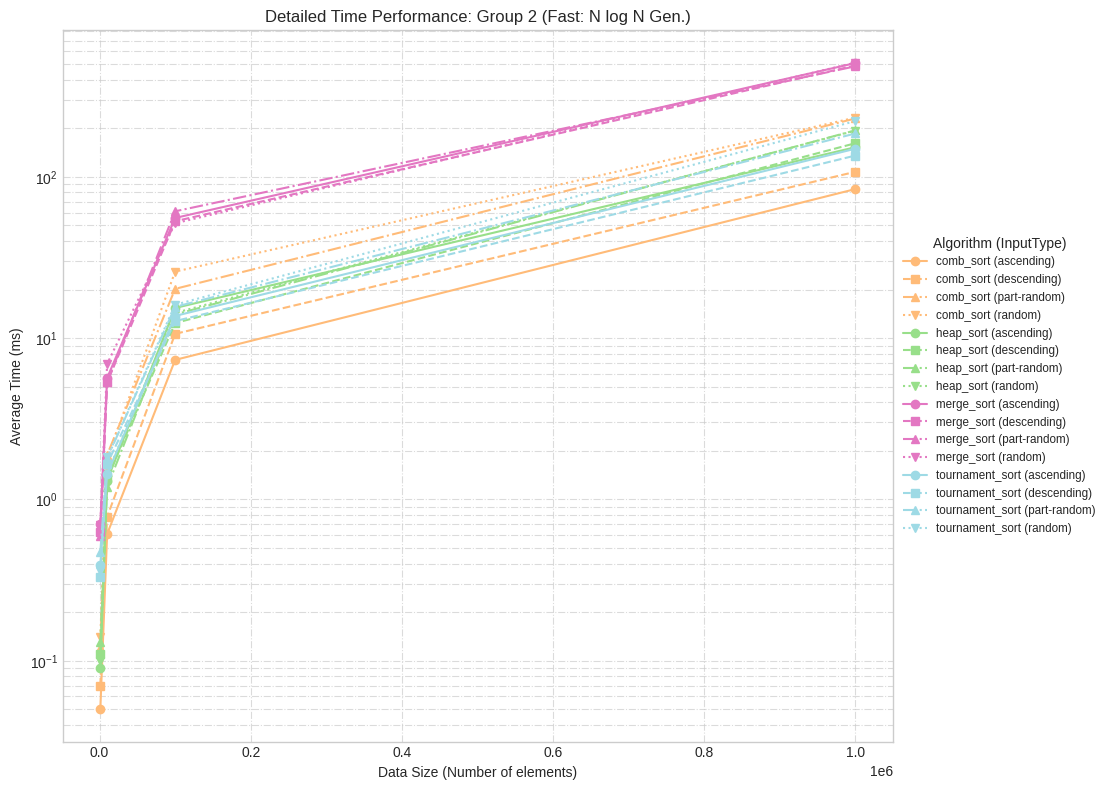


 plotting and saving 'Group 3 (Quadratic: Better Cases)' to 'time_plot_group_3_quadratic_better_cases.png'...
그래프 저장 완료: time_plot_group_3_quadratic_better_cases.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: time_plot_group_3_quadratic_better_cases.png


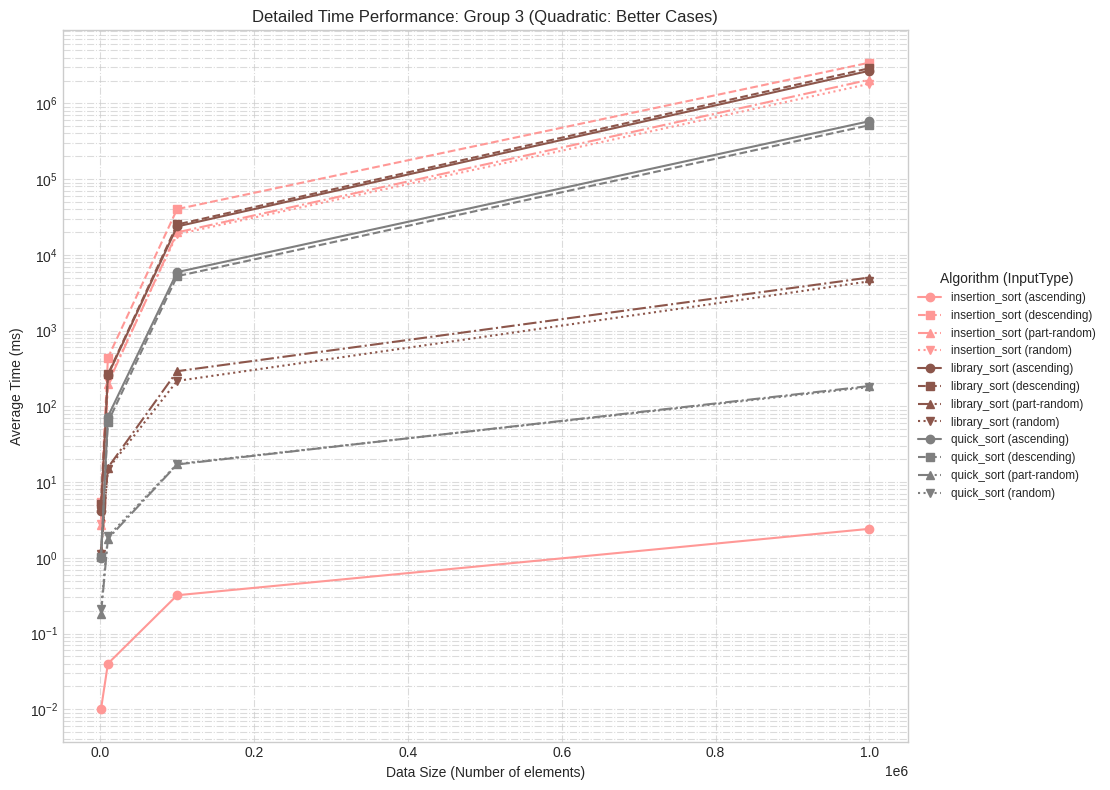


 plotting and saving 'Group 4 (Quadratic: Slowest)' to 'time_plot_group_4_quadratic_slowest.png'...
그래프 저장 완료: time_plot_group_4_quadratic_slowest.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: time_plot_group_4_quadratic_slowest.png


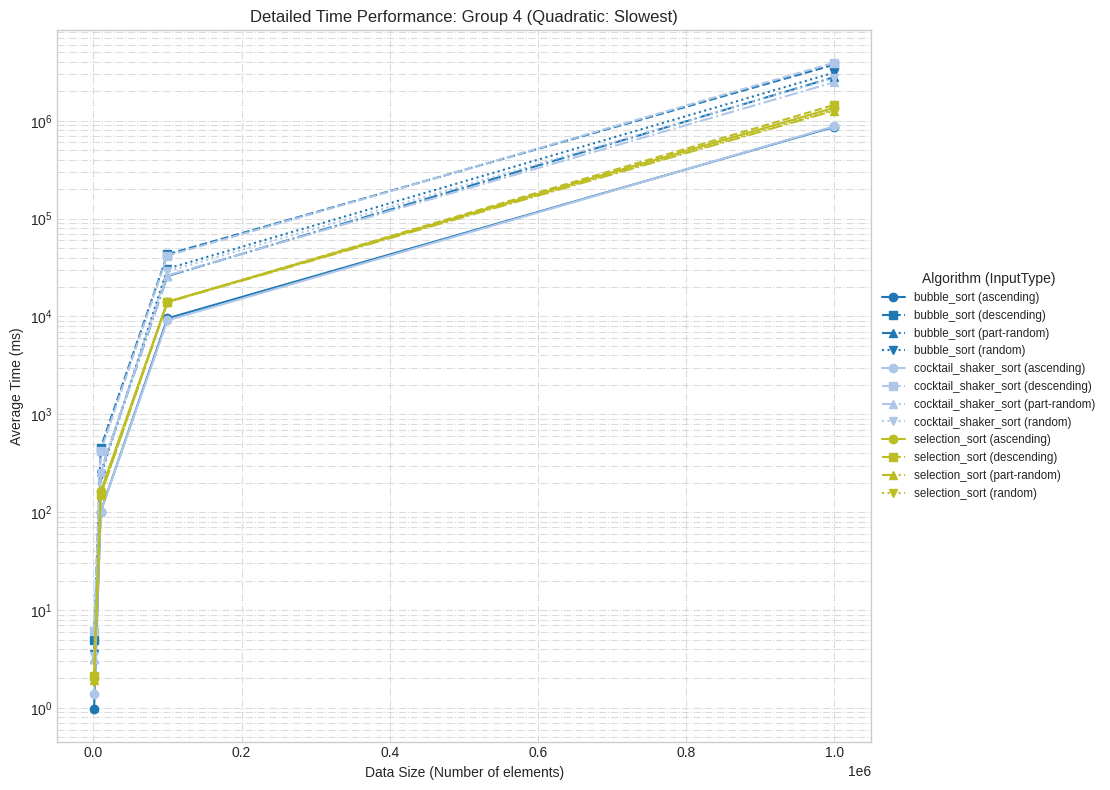


--- 상세 그룹별 그래프 생성 및 저장/다운로드 완료 ---


In [ ]:
# ============================
# Cell: 상세 그룹별 시간 그래프 생성 + 각 그룹 저장 및 다운로드
# ============================

# 필요한 라이브러리 임포트
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from google.colab import files # 다운로드 위해 추가
import re # 파일 이름 생성을 위해 추가

# --- 상세 그룹 정의 ---
detailed_groups = {
    "Group 1 (Fastest: N log N Opt.)": ['tim_sort', 'introsort'],
    "Group 2 (Fast: N log N Gen.)": ['heap_sort', 'comb_sort', 'tournament_sort', 'merge_sort'],
    "Group 3 (Quadratic: Better Cases)": ['insertion_sort', 'library_sort', 'quick_sort'],
    "Group 4 (Quadratic: Slowest)": ['bubble_sort', 'cocktail_shaker_sort', 'selection_sort']
}

# --- 상세 그룹 플로팅 함수 (저장/다운로드 기능 추가) ---
def plot_detailed_time_group(data, algorithms_to_plot, group_name, use_log_scale=True, filename=None):
    """
    지정된 알고리즘의 상세 그룹에 대한 시간 그래프 생성.
    선택적으로 파일 저장 및 다운로드 기능 포함.
    """
    # 필요한 변수 확인
    if 'cleaned_data' not in globals() or not isinstance(data, pd.DataFrame) or data.empty:
        print("오류: 'cleaned_data'가 준비되지 않았습니다.")
        return
    if 'algo_colors' not in globals() or not isinstance(algo_colors, dict):
        print("오류: 'algo_colors'가 준비되지 않았습니다.")
        cmap_temp = plt.cm.get_cmap('tab10', len(algorithms_to_plot))
        temp_colors = {algo: cmap_temp(i) for i, algo in enumerate(algorithms_to_plot)}
    else:
        temp_colors = algo_colors

    # Figure와 Axes 객체 생성
    fig, ax = plt.subplots(figsize=(14, 8))

    # 데이터 필터링
    filtered_data = data[data['Algorithm'].isin(algorithms_to_plot)]
    if filtered_data.empty:
        print(f"그룹 '{group_name}'에 해당하는 데이터가 없습니다.")
        plt.close(fig)
        return

    input_types = sorted(filtered_data['InputType'].unique())
    present_algorithms = sorted(filtered_data['Algorithm'].unique())
    markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'X']
    linestyles = ['-', '--', '-.', ':']

    # 데이터 플로팅
    for i, algo in enumerate(present_algorithms):
        algo_data = filtered_data[filtered_data['Algorithm'] == algo]
        if algo_data.empty: continue
        for j, input_type in enumerate(input_types):
            subset = algo_data[algo_data['InputType'] == input_type].sort_values('DataSize')
            if not subset.empty:
                marker_idx = j % len(markers)
                linestyle_idx = j % len(linestyles)
                label = f"{algo} ({input_type})"
                ax.plot(subset['DataSize'], subset['AverageTime(ms)'],
                        marker=markers[marker_idx],
                        linestyle=linestyles[linestyle_idx],
                        color=temp_colors.get(algo, 'gray'),
                        label=label)

    # 그래프 속성 설정 (ax 사용)
    ax.set_xlabel('Data Size (Number of elements)')
    ax.set_ylabel('Average Time (ms)')
    ax.set_title(f'Detailed Time Performance: {group_name}')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

    if use_log_scale:
        ax.set_yscale('log')
        ax.grid(True, which="both", ls="-.", alpha=0.7)
    else:
        ax.grid(True)

    ax.legend(title='Algorithm (InputType)', loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
    fig.tight_layout(rect=[0, 0, 0.80, 1])

    # --- 파일 저장 및 다운로드 로직 (show 전에 실행) ---
    if filename:
        try:
            # 1. 파일 저장
            fig.savefig(filename, bbox_inches='tight', dpi=300, transparent=True)
            print(f"그래프 저장 완료: {filename}")

            # 2. 파일 다운로드
            files.download(filename)
            print(f"파일 다운로드 시작: {filename}")
        except Exception as e:
            print(f"파일 저장 또는 다운로드 중 오류 발생: {e}")

    # --- 그래프 화면 표시 ---
    plt.show()

print("그래프 생성 함수 'plot_detailed_time_group' (저장/다운로드 기능 포함) 정의 완료.")


# --- 상세 그룹별 그래프 생성 및 저장/다운로드 실행 ---
# cleaned_data 변수가 이전 셀에서 성공적으로 생성되었는지 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty:
    print("\n--- 상세 그룹별 시간 성능 그래프 생성 및 저장/다운로드 시작 ---")

    # 정의된 각 상세 그룹에 대해 플로팅 함수 호출
    for group_name, algorithms_in_group in detailed_groups.items():
        # Y축 스케일 결정
        use_log = True
        # if group_name == "Group 5 (Quadratic: Slowest)": # 필요 시 선형 스케일 옵션
        #     use_log = False

        # --- 파일 이름 생성 (그룹 이름 기반) ---
        # 그룹 이름에서 파일명에 적합하지 않은 문자 제거/변경
        safe_group_name = re.sub(r'[^\w\s-]', '', group_name).strip() # 특수문자 제거
        safe_group_name = re.sub(r'[-\s]+', '_', safe_group_name).lower() # 공백, 하이픈을 밑줄로 변경, 소문자화
        output_filename = f"time_plot_{safe_group_name}.png" # 최종 파일 이름

        print(f"\n plotting and saving '{group_name}' to '{output_filename}'...")
        # 수정된 함수 호출 시 filename 인자 전달
        plot_detailed_time_group(cleaned_data,
                                 algorithms_in_group,
                                 group_name,
                                 use_log_scale=use_log,
                                 filename=output_filename) # 생성된 파일 이름 전달

    print("\n--- 상세 그룹별 그래프 생성 및 저장/다운로드 완료 ---")
else:
    # cleaned_data가 없거나 비어있을 경우 메시지 출력
    print("오류: 'cleaned_data'를 찾을 수 없거나 비어 있습니다. 이전 데이터 로드 및 전처리 셀을 먼저 실행해주세요.")




--- In-place/Not-in-place 메모리 그룹별 그래프 생성 및 저장/다운로드 시작 ---

 plotting and saving memory for 'Memory - In-place Algorithms' to 'memory_in_place_algorithms_plot.png'...
메모리 그래프 저장 완료: memory_in_place_algorithms_plot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: memory_in_place_algorithms_plot.png


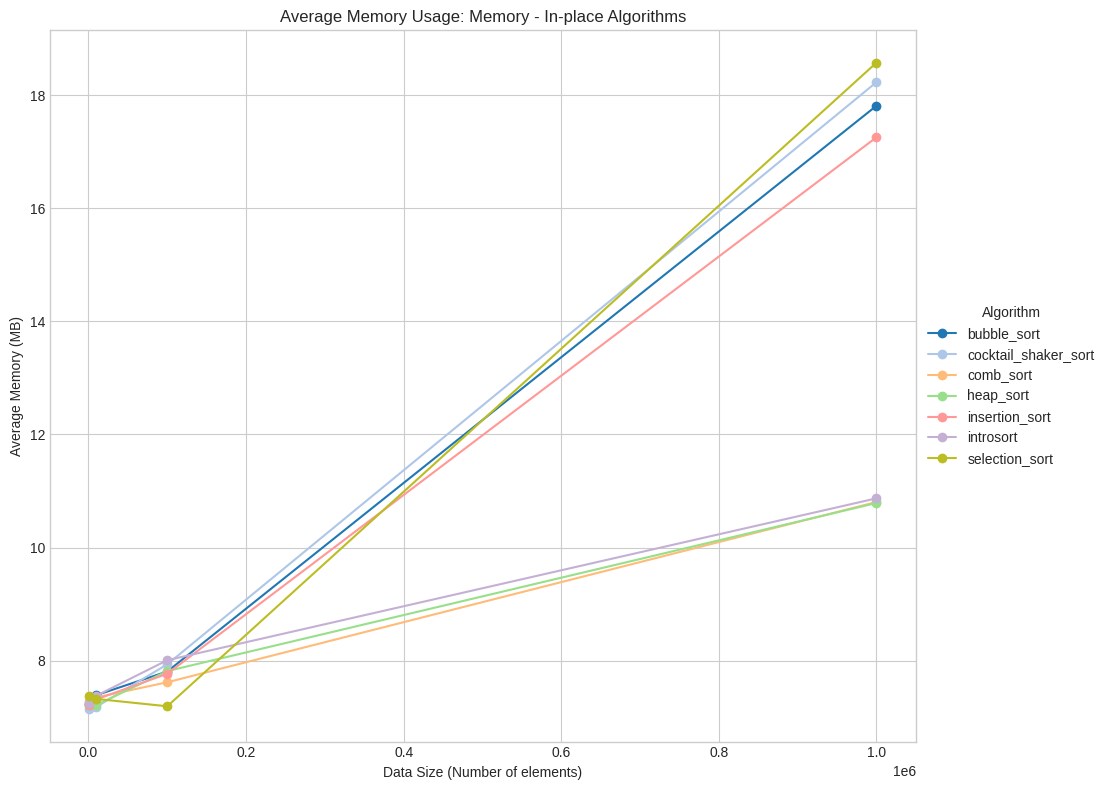


 plotting and saving memory for 'Memory - Not-in-place (excl Merge)' to 'memory_not_in_place_excl_merge_plot.png'...
메모리 그래프 저장 완료: memory_not_in_place_excl_merge_plot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: memory_not_in_place_excl_merge_plot.png


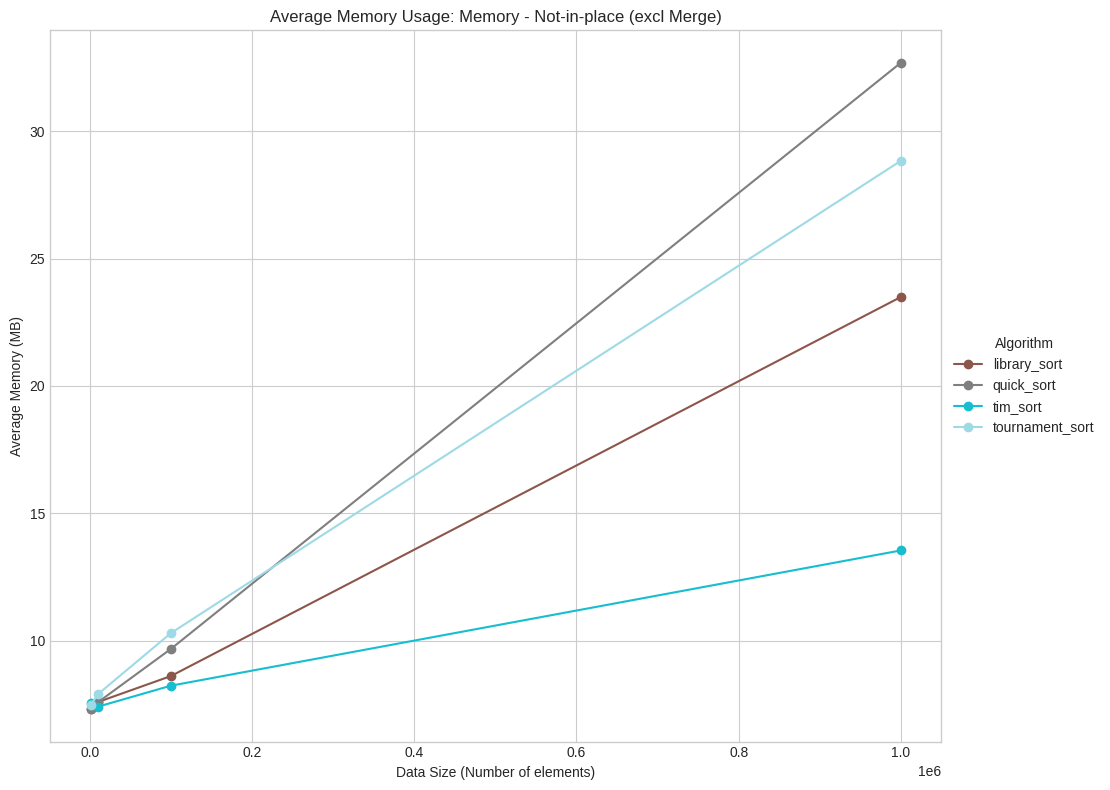


--- In-place/Not-in-place 메모리 그룹별 그래프 생성 및 저장/다운로드 완료 ---


In [ ]:
# ============================
# Cell Combined: In-place / Not-in-place 메모리 그룹별 그래프 (함수 정의 포함)
# ============================

# 필요한 라이브러리 임포트
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from google.colab import files # 다운로드 위해 추가
import re # 파일 이름 생성을 위해 추가

# --- 상세 메모리 그룹 플로팅 함수 (저장/다운로드 기능 포함) ---
# (이전에 Cell E 에서 정의했던 함수 내용)
def plot_detailed_memory_group(data, algorithms_to_plot, group_name, filename=None):
    """
    지정된 알고리즘의 상세 그룹에 대한 평균 메모리 그래프 생성.
    선택적으로 파일 저장 및 다운로드 기능 포함.
    """
    # 필요한 변수 확인
    if 'cleaned_data' not in globals() or not isinstance(data, pd.DataFrame) or data.empty:
        print("오류: 'cleaned_data'가 준비되지 않았습니다.")
        return
    if 'algo_colors' not in globals() or not isinstance(algo_colors, dict):
        print("오류: 'algo_colors'가 준비되지 않았습니다.")
        cmap_temp = plt.cm.get_cmap('tab10', len(algorithms_to_plot))
        temp_colors = {algo: cmap_temp(i) for i, algo in enumerate(algorithms_to_plot)}
    else:
        temp_colors = algo_colors

    # Figure와 Axes 객체 생성
    fig, ax = plt.subplots(figsize=(14, 8))

    # 메모리 데이터 집계
    average_memory_data = data.groupby(['Algorithm', 'DataSize'])['AverageMemory(MB)'].mean().reset_index()

    # 데이터 필터링
    filtered_memory_data = average_memory_data[average_memory_data['Algorithm'].isin(algorithms_to_plot)]
    if filtered_memory_data.empty:
        print(f"그룹 '{group_name}'에 해당하는 메모리 데이터가 없습니다.")
        plt.close(fig)
        return

    present_algorithms = sorted(filtered_memory_data['Algorithm'].unique())

    # 데이터 플로팅 (ax 사용)
    for algo in present_algorithms:
        subset = filtered_memory_data[filtered_memory_data['Algorithm'] == algo].sort_values('DataSize')
        if not subset.empty:
            ax.plot(subset['DataSize'], subset['AverageMemory(MB)'],
                    marker='o', linestyle='-', label=algo, color=temp_colors.get(algo, 'gray'))

    # 그래프 속성 설정 (ax 사용)
    ax.set_xlabel('Data Size (Number of elements)')
    ax.set_ylabel('Average Memory (MB)')
    ax.set_title(f'Average Memory Usage: {group_name}')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax.grid(True)
    ax.legend(title='Algorithm', loc='center left', bbox_to_anchor=(1, 0.5))
    fig.tight_layout(rect=[0, 0, 0.80, 1])

    # --- 파일 저장 및 다운로드 로직 (show 전에 실행) ---
    if filename:
        try:
            # 1. 파일 저장
            fig.savefig(filename, bbox_inches='tight', dpi=300, transparent=True)
            print(f"메모리 그래프 저장 완료: {filename}")

            # 2. 파일 다운로드
            files.download(filename)
            print(f"파일 다운로드 시작: {filename}")
        except Exception as e:
            print(f"파일 저장 또는 다운로드 중 오류 발생: {e}")

    # --- 화면에 그래프 표시 ---
    plt.show()

# 함수 정의 확인 메시지 (선택적)
# print("상세 메모리 그룹 플로팅 함수 'plot_detailed_memory_group' (저장/다운로드 기능 포함) 정의 완료.")


# --- 그룹 정의 (In-place vs Not-in-place, merge_sort 제외) ---
# (이전에 Cell L 에서 사용했던 그룹 정의)
inplace_algorithms = [
    'bubble_sort', 'cocktail_shaker_sort', 'selection_sort', 'insertion_sort',
    'heap_sort', 'comb_sort', 'introsort'
]
not_inplace_algorithms_excl_merge = [
    'tim_sort', 'tournament_sort', 'quick_sort', 'library_sort'
]

# 딕셔너리로 그룹 관리
memory_groups_by_placement = {
    "Memory - In-place Algorithms": inplace_algorithms,
    "Memory - Not-in-place (excl Merge)": not_inplace_algorithms_excl_merge
}


# --- 그룹별 메모리 그래프 생성 및 저장/다운로드 실행 ---
# (이전에 Cell L 에서 사용했던 호출 로직)
# 필요한 변수 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'plot_detailed_memory_group' in globals() and callable(plot_detailed_memory_group) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    print("\n--- In-place/Not-in-place 메모리 그룹별 그래프 생성 및 저장/다운로드 시작 ---")

    # 정의된 각 그룹에 대해 플로팅 함수 호출
    for group_name, algorithms_in_group in memory_groups_by_placement.items():
        # --- 파일 이름 생성 (그룹 이름 기반) ---
        safe_group_name = re.sub(r'[^\w\s-]', '', group_name).strip()
        safe_group_name = re.sub(r'[-\s]+', '_', safe_group_name).lower()
        output_filename = f"{safe_group_name}_plot.png" # 예: memory_inplace_algorithms_plot.png

        print(f"\n plotting and saving memory for '{group_name}' to '{output_filename}'...")
        # plot_detailed_memory_group 함수 호출 시 filename 인자 전달
        plot_detailed_memory_group(cleaned_data,
                                   algorithms_in_group,
                                   group_name,
                                   filename=output_filename) # 생성된 파일 이름 전달

    print("\n--- In-place/Not-in-place 메모리 그룹별 그래프 생성 및 저장/다운로드 완료 ---")
else:
    # 필요한 변수/함수가 준비되지 않았을 경우 메시지 출력
    missing = []
    if 'cleaned_data' not in globals() or not isinstance(cleaned_data, pd.DataFrame) or cleaned_data.empty:
        missing.append("'cleaned_data' DataFrame")
    if 'plot_detailed_memory_group' not in globals() or not callable(plot_detailed_memory_group):
        missing.append("'plot_detailed_memory_group' function") # 함수 정의가 이 셀에 있으므로 이 오류는 덜 발생함
    if 'algo_colors' not in globals() or not isinstance(algo_colors, dict):
        missing.append("'algo_colors' dictionary")
    print(f"오류: 그래프 생성에 필요한 {', '.join(missing)} 이(가) 준비되지 않았습니다. 이전 셀(Cell 1)을 먼저 실행해주세요.")



Log-Log 메모리 그래프 저장 완료: loglog_memory_all_algorithms.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: loglog_memory_all_algorithms.png


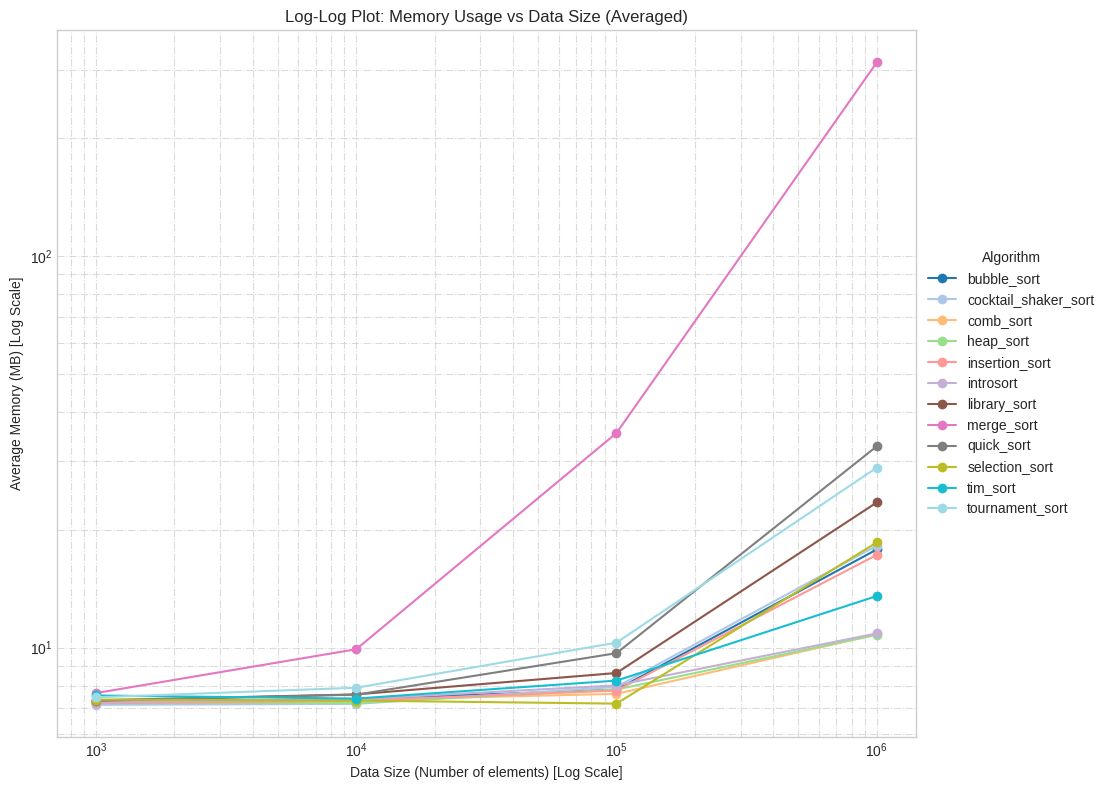

In [ ]:
# ============================
# Cell M: Log-Log 평균 메모리 그래프 (모든 알고리즘) + 저장/다운로드
# ============================

# 필요한 라이브러리 임포트 확인
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re # 파일 이름용

# 저장할 파일 이름 정의
output_loglog_memory_filename = "loglog_memory_all_algorithms.png"

# cleaned_data, algorithms, algo_colors 가 이전 셀에서 정의되었는지 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    try:
        # --- 그래프 생성 시작 ---
        fig, ax = plt.subplots(figsize=(14, 8))

        # 메모리 데이터 집계 (평균)
        average_memory = cleaned_data.groupby(['Algorithm', 'DataSize'])['AverageMemory(MB)'].mean().reset_index()

        # 각 알고리즘 플로팅
        for algo in algorithms:
            subset = average_memory[average_memory['Algorithm'] == algo].sort_values('DataSize')
            # 로그 스케일에서는 0 이하의 값을 플롯할 수 없으므로, 0보다 큰 데이터만 사용
            subset_positive = subset[subset['AverageMemory(MB)'] > 0]
            if not subset_positive.empty:
                ax.plot(subset_positive['DataSize'], subset_positive['AverageMemory(MB)'], marker='o', linestyle='-', label=algo, color=algo_colors.get(algo))

        # 그래프 속성 설정
        ax.set_xlabel('Data Size (Number of elements) [Log Scale]')
        ax.set_ylabel('Average Memory (MB) [Log Scale]')
        ax.set_title('Log-Log Plot: Memory Usage vs Data Size (Averaged)')

        # --- X축과 Y축 모두 로그 스케일 설정 ---
        ax.set_xscale('log') # [4][5][7][8]
        ax.set_yscale('log') # [4][5][7][8]

        ax.legend(title='Algorithm', loc='center left', bbox_to_anchor=(1, 0.5))
        fig.tight_layout(rect=[0, 0, 0.80, 1])
        ax.grid(True, which="both", ls="-.", alpha=0.7) # 로그 스케일용 그리드

        # --- 파일 저장 및 다운로드 (show 전에 실행) ---
        fig.savefig(output_loglog_memory_filename, bbox_inches='tight', dpi=300, transparent=True) # [6][9]
        print(f"Log-Log 메모리 그래프 저장 완료: {output_loglog_memory_filename}")
        files.download(output_loglog_memory_filename)
        print(f"파일 다운로드 시작: {output_loglog_memory_filename}")

        # --- 화면에 그래프 표시 ---
        plt.show()

    except Exception as e:
        print(f"Log-Log 메모리 그래프 생성 또는 저장/다운로드 중 오류 발생: {e}")
        if 'fig' in locals(): plt.close(fig)

else:
    print("오류: Log-Log 메모리 그래프 생성에 필요한 데이터가 준비되지 않았습니다.")



'ascending' 데이터에서 0ms 값을 0.001ms로 대체했습니다.
Log-Log 'ascending' 시간 그래프 저장 완료: loglog_time_plot_ascending.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: loglog_time_plot_ascending.png


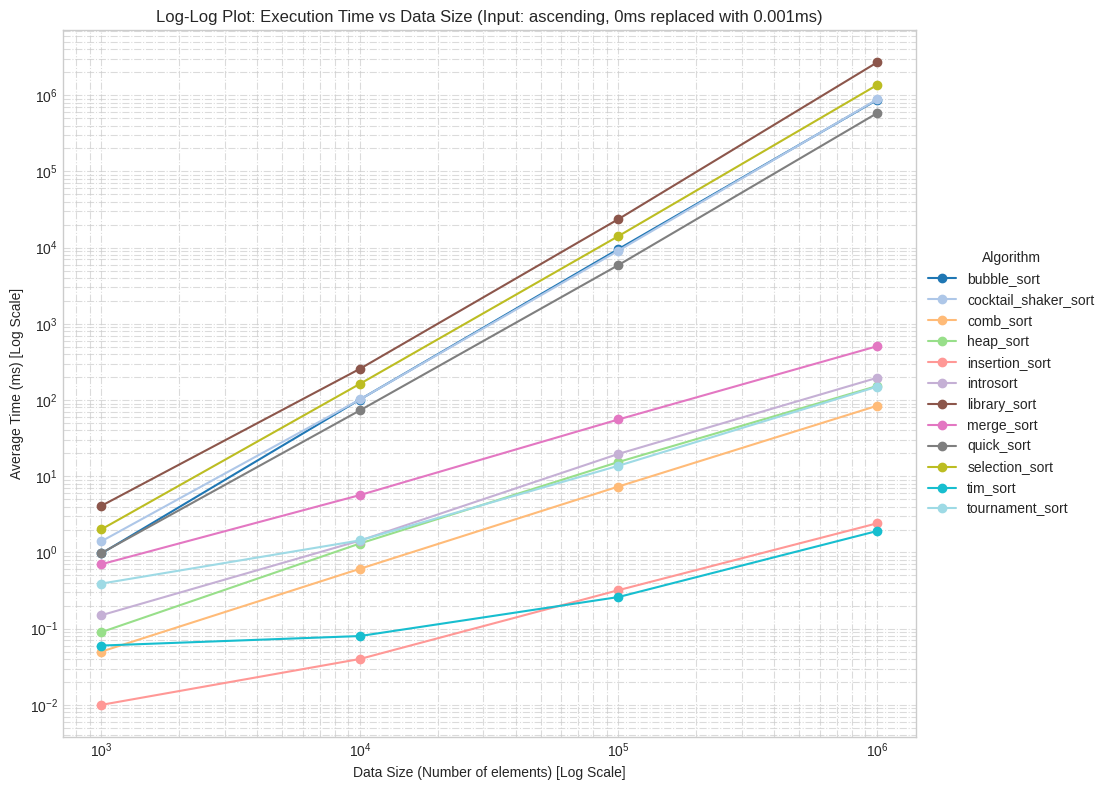

In [ ]:
# ============================
# Cell N: Log-Log 시간 그래프 (Input: ascending) + 0값 대체 및 저장/다운로드
# ============================

from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# 설정
input_type_filter = 'ascending'
safe_input_type_name = re.sub(r'\W+', '_', input_type_filter).lower()
output_loglog_time_filename = f"loglog_time_plot_{safe_input_type_name}.png"
zero_replacement_value = 0.001 # 0 대신 사용할 작은 값

# 데이터 및 변수 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    # InputType으로 데이터 필터링
    time_data_filtered = cleaned_data[cleaned_data['InputType'] == input_type_filter].copy() # SettingWithCopyWarning 방지 위해 .copy()

    if not time_data_filtered.empty:
        try:
            # --- 0 값 대체 로직 추가 ---
            # 'AverageTime(ms)' 열에서 0인 값을 zero_replacement_value 로 변경
            time_data_filtered.loc[time_data_filtered['AverageTime(ms)'] == 0, 'AverageTime(ms)'] = zero_replacement_value # [3] 유사 로직
            print(f"'{input_type_filter}' 데이터에서 0ms 값을 {zero_replacement_value}ms로 대체했습니다.")

            # --- 그래프 생성 ---
            fig, ax = plt.subplots(figsize=(14, 8))

            # 알고리즘별 플로팅
            for algo in algorithms:
                subset = time_data_filtered[time_data_filtered['Algorithm'] == algo].sort_values('DataSize')
                # 0 값 대체 후에는 0보다 큰 값 필터링이 여전히 유효 (혹시 모를 음수 값 대비)
                # 또는 이 필터링을 제거해도 됨 (0이 없으므로)
                subset_positive = subset[subset['AverageTime(ms)'] > 0]
                if not subset_positive.empty:
                    ax.plot(subset_positive['DataSize'], subset_positive['AverageTime(ms)'], marker='o', linestyle='-', label=algo, color=algo_colors.get(algo))

            # 속성 설정
            ax.set_xlabel('Data Size (Number of elements) [Log Scale]')
            ax.set_ylabel('Average Time (ms) [Log Scale]')
            ax.set_title(f'Log-Log Plot: Execution Time vs Data Size (Input: {input_type_filter}, 0ms replaced with {zero_replacement_value}ms)') # 제목에 명시

            # --- X축과 Y축 모두 로그 스케일 설정 ---
            ax.set_xscale('log')
            ax.set_yscale('log')

            ax.legend(title='Algorithm', loc='center left', bbox_to_anchor=(1, 0.5))
            fig.tight_layout(rect=[0, 0, 0.80, 1])
            ax.grid(True, which="both", ls="-.", alpha=0.7)

            # --- 파일 저장 및 다운로드 ---
            fig.savefig(output_loglog_time_filename, bbox_inches='tight', dpi=300, transparent=True)
            print(f"Log-Log '{input_type_filter}' 시간 그래프 저장 완료: {output_loglog_time_filename}")
            files.download(output_loglog_time_filename)
            print(f"파일 다운로드 시작: {output_loglog_time_filename}")

            # --- 그래프 표시 ---
            plt.show()

        except Exception as e:
            print(f"Log-Log '{input_type_filter}' 시간 그래프 오류: {e}")
            if 'fig' in locals(): plt.close(fig)
    else:
        print(f"'{input_type_filter}' 타입 데이터 없음.")
else:
    print("오류: Log-Log 시간 그래프 생성 필요 데이터 미준비.")



Log-Log 'descending' 시간 그래프 저장 완료: loglog_time_plot_descending.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: loglog_time_plot_descending.png


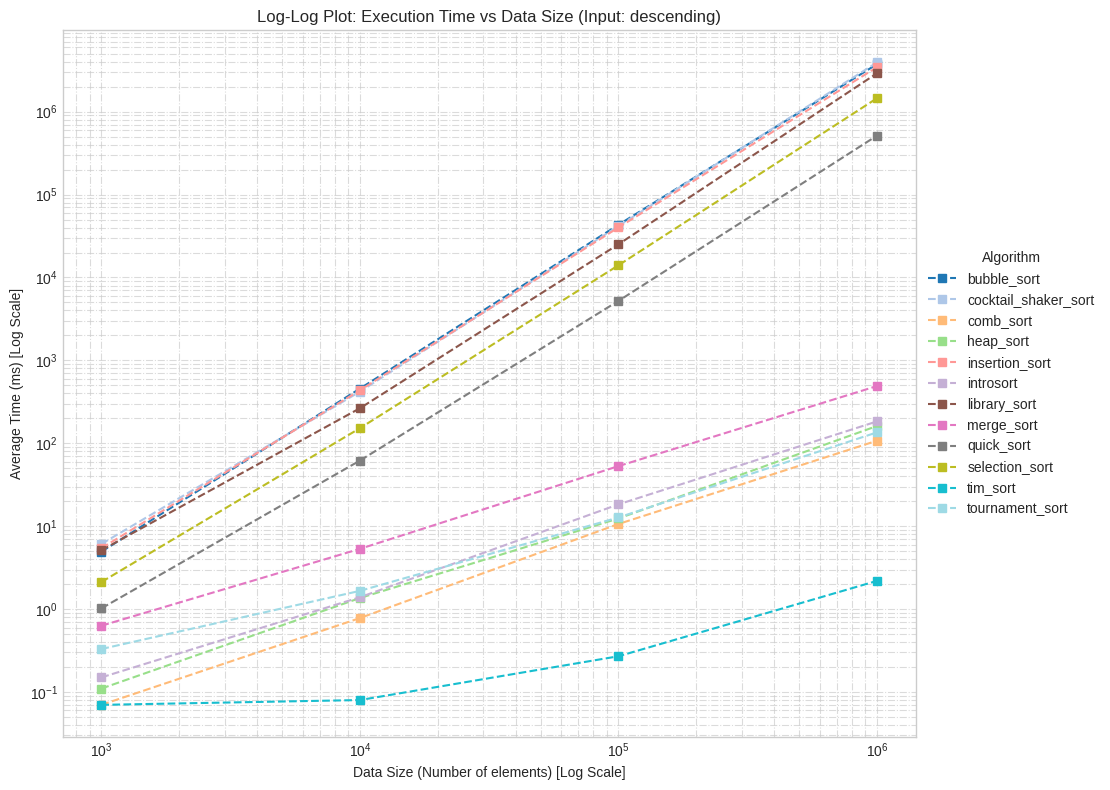

In [ ]:
# ============================
# Cell O: Log-Log 시간 그래프 (Input: descending) + 저장/다운로드
# ============================

from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# 설정
input_type_filter = 'descending'
safe_input_type_name = re.sub(r'\W+', '_', input_type_filter).lower()
output_loglog_time_filename = f"loglog_time_plot_{safe_input_type_name}.png"

# 데이터 및 변수 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    time_data_filtered = cleaned_data[cleaned_data['InputType'] == input_type_filter]

    if not time_data_filtered.empty:
        try:
            fig, ax = plt.subplots(figsize=(14, 8))
            for algo in algorithms:
                subset = time_data_filtered[time_data_filtered['Algorithm'] == algo].sort_values('DataSize')
                subset_positive = subset[subset['AverageTime(ms)'] > 0]
                if not subset_positive.empty:
                    # 마커/스타일 변경 (선택적)
                    ax.plot(subset_positive['DataSize'], subset_positive['AverageTime(ms)'], marker='s', linestyle='--', label=algo, color=algo_colors.get(algo))

            ax.set_xlabel('Data Size (Number of elements) [Log Scale]')
            ax.set_ylabel('Average Time (ms) [Log Scale]')
            ax.set_title(f'Log-Log Plot: Execution Time vs Data Size (Input: {input_type_filter})')
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.legend(title='Algorithm', loc='center left', bbox_to_anchor=(1, 0.5))
            fig.tight_layout(rect=[0, 0, 0.80, 1])
            ax.grid(True, which="both", ls="-.", alpha=0.7)

            fig.savefig(output_loglog_time_filename, bbox_inches='tight', dpi=300, transparent=True)
            print(f"Log-Log '{input_type_filter}' 시간 그래프 저장 완료: {output_loglog_time_filename}")
            files.download(output_loglog_time_filename)
            print(f"파일 다운로드 시작: {output_loglog_time_filename}")
            plt.show()

        except Exception as e:
            print(f"Log-Log '{input_type_filter}' 시간 그래프 오류: {e}")
            if 'fig' in locals(): plt.close(fig)
    else:
        print(f"'{input_type_filter}' 타입 데이터 없음.")
else:
    print("오류: Log-Log 시간 그래프 생성 필요 데이터 미준비.")


Log-Log 'random' 시간 그래프 저장 완료: loglog_time_plot_random.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: loglog_time_plot_random.png


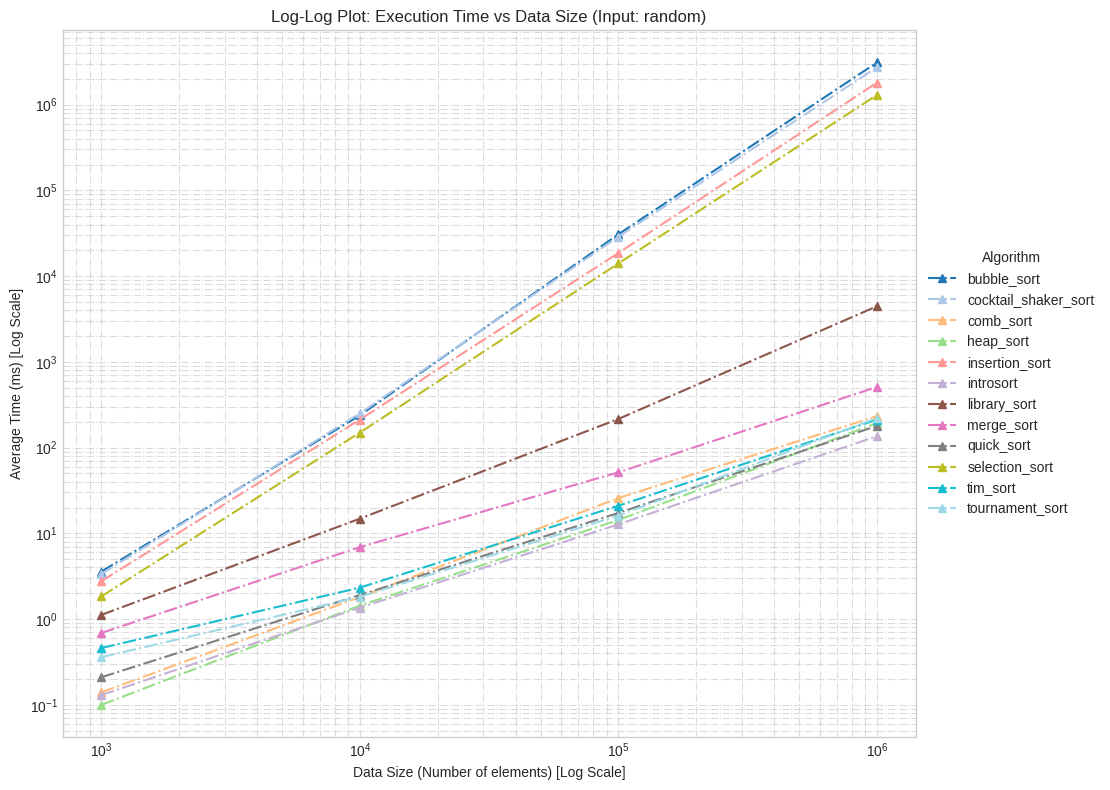

In [ ]:
# ============================
# Cell P: Log-Log 시간 그래프 (Input: random) + 저장/다운로드
# ============================

from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# 설정
input_type_filter = 'random'
safe_input_type_name = re.sub(r'\W+', '_', input_type_filter).lower()
output_loglog_time_filename = f"loglog_time_plot_{safe_input_type_name}.png"

# 데이터 및 변수 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    time_data_filtered = cleaned_data[cleaned_data['InputType'] == input_type_filter]

    if not time_data_filtered.empty:
        try:
            fig, ax = plt.subplots(figsize=(14, 8))
            for algo in algorithms:
                subset = time_data_filtered[time_data_filtered['Algorithm'] == algo].sort_values('DataSize')
                subset_positive = subset[subset['AverageTime(ms)'] > 0]
                if not subset_positive.empty:
                    # 마커/스타일 변경 (선택적)
                    ax.plot(subset_positive['DataSize'], subset_positive['AverageTime(ms)'], marker='^', linestyle='-.', label=algo, color=algo_colors.get(algo))

            ax.set_xlabel('Data Size (Number of elements) [Log Scale]')
            ax.set_ylabel('Average Time (ms) [Log Scale]')
            ax.set_title(f'Log-Log Plot: Execution Time vs Data Size (Input: {input_type_filter})')
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.legend(title='Algorithm', loc='center left', bbox_to_anchor=(1, 0.5))
            fig.tight_layout(rect=[0, 0, 0.80, 1])
            ax.grid(True, which="both", ls="-.", alpha=0.7)

            fig.savefig(output_loglog_time_filename, bbox_inches='tight', dpi=300, transparent=True)
            print(f"Log-Log '{input_type_filter}' 시간 그래프 저장 완료: {output_loglog_time_filename}")
            files.download(output_loglog_time_filename)
            print(f"파일 다운로드 시작: {output_loglog_time_filename}")
            plt.show()

        except Exception as e:
            print(f"Log-Log '{input_type_filter}' 시간 그래프 오류: {e}")
            if 'fig' in locals(): plt.close(fig)
    else:
        print(f"'{input_type_filter}' 타입 데이터 없음.")
else:
    print("오류: Log-Log 시간 그래프 생성 필요 데이터 미준비.")


Log-Log 'part-random' 시간 그래프 저장 완료: loglog_time_plot_part_random.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: loglog_time_plot_part_random.png


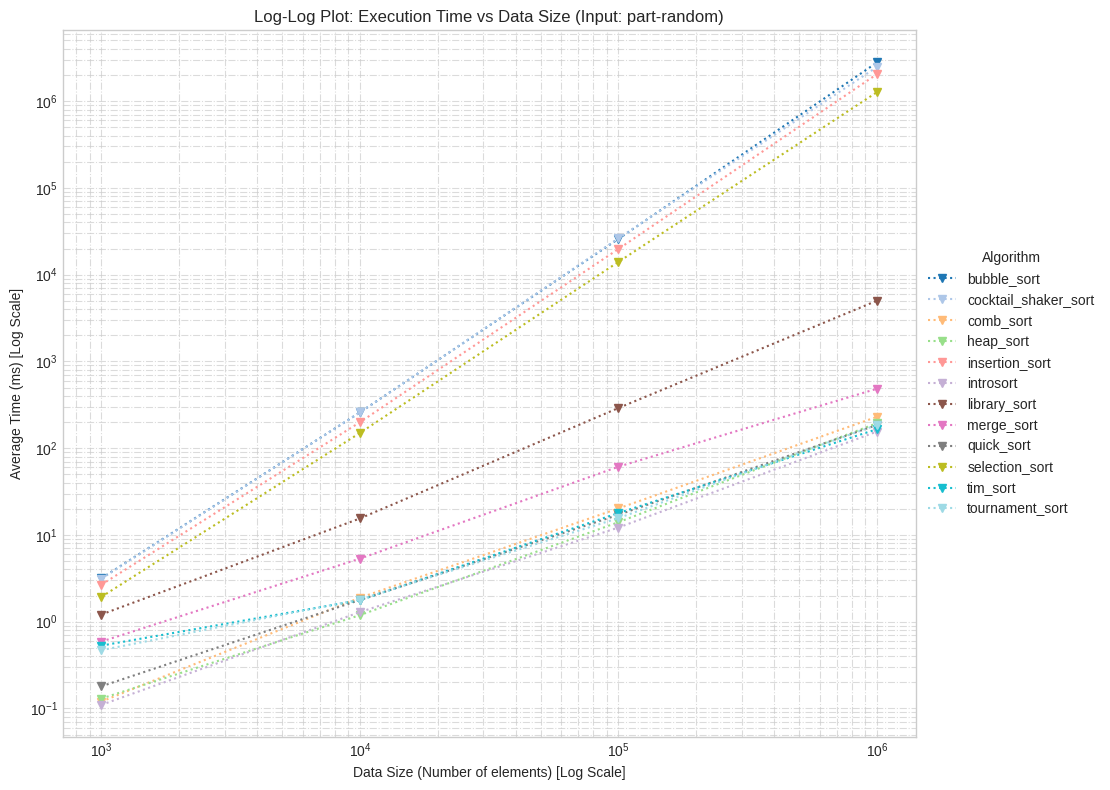

In [ ]:
# ============================
# Cell Q: Log-Log 시간 그래프 (Input: part-random) + 저장/다운로드
# ============================

from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# 설정
input_type_filter = 'part-random'
safe_input_type_name = re.sub(r'\W+', '_', input_type_filter).lower()
output_loglog_time_filename = f"loglog_time_plot_{safe_input_type_name}.png"

# 데이터 및 변수 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    time_data_filtered = cleaned_data[cleaned_data['InputType'] == input_type_filter]

    if not time_data_filtered.empty:
        try:
            fig, ax = plt.subplots(figsize=(14, 8))
            for algo in algorithms:
                subset = time_data_filtered[time_data_filtered['Algorithm'] == algo].sort_values('DataSize')
                subset_positive = subset[subset['AverageTime(ms)'] > 0]
                if not subset_positive.empty:
                    # 마커/스타일 변경 (선택적)
                    ax.plot(subset_positive['DataSize'], subset_positive['AverageTime(ms)'], marker='v', linestyle=':', label=algo, color=algo_colors.get(algo))

            ax.set_xlabel('Data Size (Number of elements) [Log Scale]')
            ax.set_ylabel('Average Time (ms) [Log Scale]')
            ax.set_title(f'Log-Log Plot: Execution Time vs Data Size (Input: {input_type_filter})')
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.legend(title='Algorithm', loc='center left', bbox_to_anchor=(1, 0.5))
            fig.tight_layout(rect=[0, 0, 0.80, 1])
            ax.grid(True, which="both", ls="-.", alpha=0.7)

            fig.savefig(output_loglog_time_filename, bbox_inches='tight', dpi=300, transparent=True)
            print(f"Log-Log '{input_type_filter}' 시간 그래프 저장 완료: {output_loglog_time_filename}")
            files.download(output_loglog_time_filename)
            print(f"파일 다운로드 시작: {output_loglog_time_filename}")
            plt.show()

        except Exception as e:
            print(f"Log-Log '{input_type_filter}' 시간 그래프 오류: {e}")
            if 'fig' in locals(): plt.close(fig)
    else:
        print(f"'{input_type_filter}' 타입 데이터 없음.")
else:
    print("오류: Log-Log 시간 그래프 생성 필요 데이터 미준비.")


알고리즘 구분 Log-Log 산점도 (고해상도) 저장 완료: time_vs_memory_scatter_loglog_by_algorithm_high_res.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: time_vs_memory_scatter_loglog_by_algorithm_high_res.png


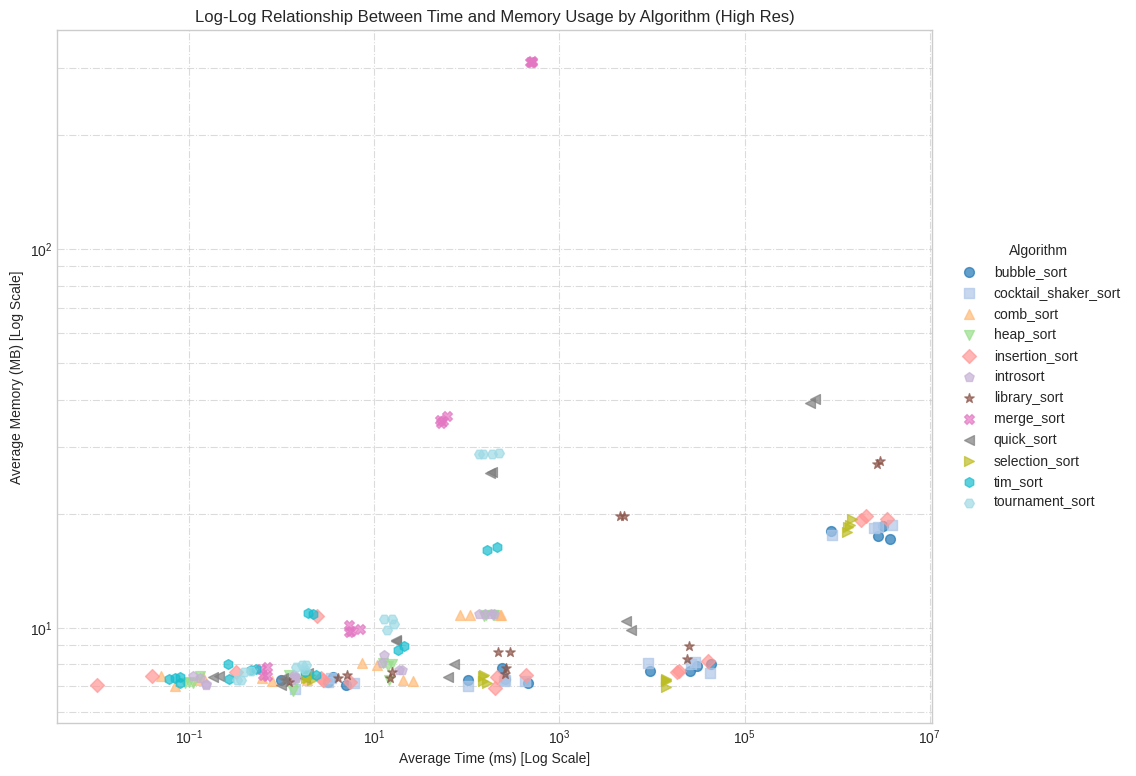

In [ ]:
# ============================
# Cell T: 시간-메모리 관계 산점도 (Log-Log, 알고리즘 구분) + 고해상도 저장/다운로드
# ============================

# 필요한 라이브러리 임포트 확인
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re # 파일 이름용

# 저장할 파일 이름 정의
output_scatter_loglog_algo_filename = "time_vs_memory_scatter_loglog_by_algorithm_high_res.png" # 파일명 변경 (선택적)
high_dpi_value = 300 # 고해상도 DPI 값 설정

# cleaned_data, algorithms, algo_colors 가 이전 셀에서 정의되었는지 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    # 로그 스케일 적용 위해 시간과 메모리가 0보다 큰 데이터만 사용
    plot_data_log_algo = cleaned_data[(cleaned_data['AverageTime(ms)'] > 0) & (cleaned_data['AverageMemory(MB)'] > 0)].copy()

    if not plot_data_log_algo.empty:
        try:
            # --- 그래프 생성 시작 ---
            fig, ax = plt.subplots(figsize=(14, 9)) # 범례 공간 고려하여 크기 조정

            markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'X', '<', '>', 'h', 'H', '+', 'd']

            # 각 알고리즘별로 다른 색상과 마커로 산점도 그리기
            for i, algo in enumerate(algorithms):
                algo_data = plot_data_log_algo[plot_data_log_algo['Algorithm'] == algo]
                if not algo_data.empty:
                    marker_style = markers[i % len(markers)]
                    ax.scatter(algo_data['AverageTime(ms)'], algo_data['AverageMemory(MB)'],
                               alpha=0.7,
                               color=algo_colors.get(algo, 'gray'),
                               marker=marker_style,
                               label=algo,
                               s=50)

            # X축과 Y축 모두 로그 스케일 설정
            ax.set_xscale('log')
            ax.set_yscale('log')

            # 그래프 속성 설정
            ax.set_xlabel('Average Time (ms) [Log Scale]')
            ax.set_ylabel('Average Memory (MB) [Log Scale]')
            ax.set_title('Log-Log Relationship Between Time and Memory Usage by Algorithm (High Res)') # 제목 수정
            ax.grid(True, which="both", ls="-.", alpha=0.7)

            # 범례 설정
            ax.legend(title='Algorithm', loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

            # 레이아웃 조정
            plt.subplots_adjust(right=0.75)

            # --- 파일 저장 및 다운로드 (show 전에 실행) ---
            # <<<--- DPI 값 변경 부분 ---<<<
            fig.savefig(output_scatter_loglog_algo_filename, bbox_inches='tight', dpi=high_dpi_value) # dpi 값을 300으로 설정
            # <<<-------------------------<<<
            print(f"알고리즘 구분 Log-Log 산점도 (고해상도) 저장 완료: {output_scatter_loglog_algo_filename}")
            files.download(output_scatter_loglog_algo_filename)
            print(f"파일 다운로드 시작: {output_scatter_loglog_algo_filename}")

            # --- 화면에 그래프 표시 ---
            plt.show()

        except Exception as e:
            print(f"알고리즘 구분 Log-Log 산점도 생성 또는 저장/다운로드 중 오류 발생: {e}")
            if 'fig' in locals(): plt.close(fig)
    else:
        print("플롯할 유효한 데이터(시간 및 메모리 > 0)가 없습니다.")
else:
    print("오류: 산점도 생성에 필요한 데이터(cleaned_data, algorithms, algo_colors)가 준비되지 않았습니다.")



Original Log-Log Regression: Slope=0.0575, Intercept=0.9131
Manually Adjusted Regression: Slope=0.0575, Intercept=0.9431
Setting Y-axis lower limit to 5.78MB.
수동 조정 회귀선 포함 Log-Log 산점도 (고해상도) 저장 완료: time_vs_memory_scatter_loglog_manual_regression.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

파일 다운로드 시작: time_vs_memory_scatter_loglog_manual_regression.png


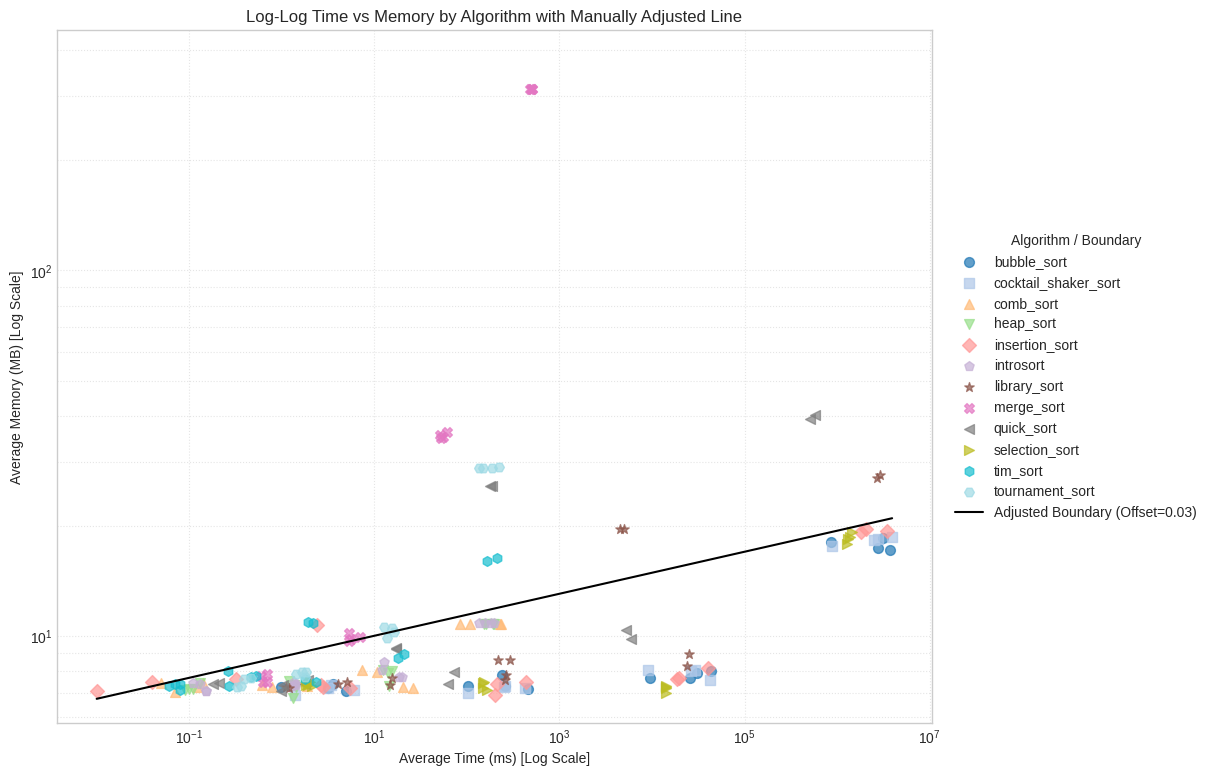

In [ ]:
# ============================
# Cell W: 시간-메모리 산점도 (Log-Log, 알고리즘 구분, 수동 조정된 회귀선) + 고해상도 저장/다운로드
# ============================

# 필요한 라이브러리 임포트 확인
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re # 파일 이름용
from scipy.stats import linregress # 원본 회귀 분석 위해 추가

# 저장할 파일 이름 및 DPI 정의
output_scatter_loglog_manual_reg_filename = "time_vs_memory_scatter_loglog_manual_regression.png"
high_dpi_value = 300

# cleaned_data, algorithms, algo_colors 가 이전 셀에서 정의되었는지 확인
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    # 로그 스케일 적용 위해 시간과 메모리가 0보다 큰 데이터만 사용
    plot_data_log_reg = cleaned_data[(cleaned_data['AverageTime(ms)'] > 0) & (cleaned_data['AverageMemory(MB)'] > 0)].copy()

    if not plot_data_log_reg.empty:
        try:
            # --- 로그 변환된 데이터 준비 ---
            log_time = np.log10(plot_data_log_reg['AverageTime(ms)'])
            log_memory = np.log10(plot_data_log_reg['AverageMemory(MB)'])

            # --- 원본 로그 변환된 데이터에 대한 선형 회귀 수행 ---
            original_slope, original_intercept, r_value, p_value, std_err = linregress(log_time, log_memory)
            print(f"Original Log-Log Regression: Slope={original_slope:.4f}, Intercept={original_intercept:.4f}")

            # --- 회귀선 파라미터 수동 조정 (절편 조정 사용) ---
            # 이 값을 조정하여 선의 높낮이를 변경 (양수: 위로 이동)
            intercept_slope = 0.01
            intercept_adjustment = 0.03 # <<<--- 주석 제거 후 이 값을 조정하세요 (예: 0.1, 0.2, 0.25 ...)

            adjusted_slope = original_slope #+ intercept_slope # 기울기는 원본 유지
            adjusted_intercept = original_intercept + intercept_adjustment # 절편 조정

            print(f"Manually Adjusted Regression: Slope={adjusted_slope:.4f}, Intercept={adjusted_intercept:.4f}")

            # --- 조정된 회귀선 생성 (로그 스케일에서) ---
            log_time_range = np.linspace(log_time.min(), log_time.max(), 100)
            adjusted_log_memory_pred = adjusted_slope * log_time_range + adjusted_intercept

            # --- 그래프 생성 시작 ---
            fig, ax = plt.subplots(figsize=(14, 9))

            markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'X', '<', '>', 'h', 'H', '+', 'd']

            # 각 알고리즘별로 산점도 그리기
            for i, algo in enumerate(algorithms):
                algo_data = plot_data_log_reg[plot_data_log_reg['Algorithm'] == algo]
                if not algo_data.empty:
                    marker_style = markers[i % len(markers)]
                    ax.scatter(algo_data['AverageTime(ms)'], algo_data['AverageMemory(MB)'],
                               alpha=0.7,
                               color=algo_colors.get(algo, 'gray'),
                               marker=marker_style,
                               label=algo,
                               s=50)

            # --- 조정된 회귀선 그리기 ---
            time_range = 10**log_time_range
            adjusted_memory_pred = 10**adjusted_log_memory_pred
            # 스타일은 검은 실선으로 변경 (참조 이미지 스타일)
            ax.plot(time_range, adjusted_memory_pred, color='black', linestyle='-', linewidth=1.5, label=f'Adjusted Boundary (Offset={intercept_adjustment:.2f})')

            # --- X축과 Y축 모두 로그 스케일 설정 ---
            ax.set_xscale('log')
            ax.set_yscale('log')

            # --- Y축 하단 한계 설정 ---
            min_observed_memory = plot_data_log_reg['AverageMemory(MB)'].min()
            y_lower_limit = max(1, min_observed_memory - 1) # 최소 1 또는 관측 최소값 - 1
            current_ylim = ax.get_ylim()
            y_upper_limit = max(current_ylim[1], adjusted_memory_pred.max()) * 1.2 # 상한 조정
            ax.set_ylim(bottom=y_lower_limit, top=y_upper_limit)
            print(f"Setting Y-axis lower limit to {y_lower_limit:.2f}MB.")

            # 그래프 속성 설정
            ax.set_xlabel('Average Time (ms) [Log Scale]')
            ax.set_ylabel('Average Memory (MB) [Log Scale]')
            ax.set_title('Log-Log Time vs Memory by Algorithm with Manually Adjusted Line')
            ax.grid(True, which="both", ls=":", alpha=0.5) # 점선 그리드

            # --- 범례 설정 ---
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles, labels, title='Algorithm / Boundary', loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

            # 레이아웃 조정
            plt.subplots_adjust(right=0.75)

            # --- 파일 저장 및 다운로드 ---
            fig.savefig(output_scatter_loglog_manual_reg_filename, bbox_inches='tight', dpi=high_dpi_value)
            print(f"수동 조정 회귀선 포함 Log-Log 산점도 (고해상도) 저장 완료: {output_scatter_loglog_manual_reg_filename}")
            files.download(output_scatter_loglog_manual_reg_filename)
            print(f"파일 다운로드 시작: {output_scatter_loglog_manual_reg_filename}")

            # --- 화면에 그래프 표시 ---
            plt.show()

        except Exception as e:
            print(f"수동 조정 회귀선 포함 Log-Log 산점도 생성 또는 저장/다운로드 중 오류 발생: {e}")
            if 'fig' in locals(): plt.close(fig)
    else:
        print("플롯할 유효한 데이터(시간 및 메모리 > 0)가 없습니다.")
else:
    print("오류: 산점도 생성에 필요한 데이터(cleaned_data, algorithms, algo_colors)가 준비되지 않았습니다.")


Filtering data for algorithms: ['tim_sort', 'library_sort', 'quick_sort', 'introsort']
Filtering data for input types: ['random', 'part-random']
Filtered data contains 32 rows.
Using markers: {'random': '^', 'part-random': 'v'}
Generating subset Log-Log time plot...
Saving graph to 'loglog_time_subset_algo_rp_high_res.png'...
Graph saved successfully (High Resolution).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started for 'loglog_time_subset_algo_rp_high_res.png'.


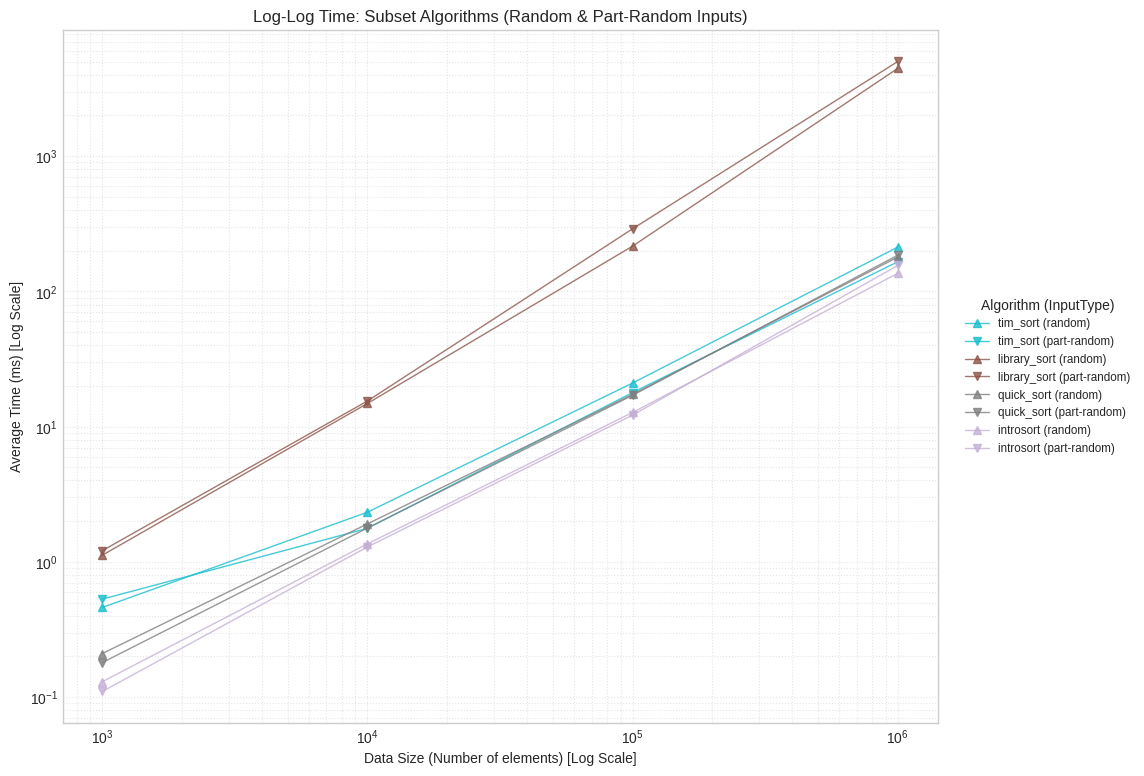

In [8]:
# ============================
# Cell Subset Plot: 특정 알고리즘('tim', 'library', 'quick', 'intro') 및 'random'/'part-random' 시간 그래프 (Cell 1 실행 후)
# ============================

# 필요한 라이브러리 임포트 확인
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re # 파일 이름용

# --- 설정 ---
zero_replacement_value = 0.001 # 0ms 대체 값
output_subset_filename = "loglog_time_subset_algo_rp_high_res.png" # 저장 파일명 변경
high_dpi_value = 300 # 고해상도 DPI

# --- 플롯할 알고리즘 및 입력 타입 정의 ---
target_algorithms = ['tim_sort', 'library_sort', 'quick_sort', 'introsort']
target_input_types = ['random', 'part-random']

# --- 플로팅 준비 (Cell 1에서 생성된 변수 사용 확인) ---
if 'cleaned_data' in globals() and isinstance(cleaned_data, pd.DataFrame) and not cleaned_data.empty \
   and 'algorithms' in globals() and isinstance(algorithms, list) \
   and 'algo_colors' in globals() and isinstance(algo_colors, dict):

    # --- 데이터 필터링 (Target 알고리즘 및 Target 입력 타입만 선택) ---
    print(f"Filtering data for algorithms: {target_algorithms}")
    print(f"Filtering data for input types: {target_input_types}")
    filtered_data_subset = cleaned_data[
        cleaned_data['Algorithm'].isin(target_algorithms) &
        cleaned_data['InputType'].isin(target_input_types)
    ].copy()
    print(f"Filtered data contains {len(filtered_data_subset)} rows.")

    # 마커 맵 (Target 입력 타입 기준)
    markers_subset = ['^', 'v'] # random='^', part-random='v' 가정
    if len(target_input_types) == 2:
         input_type_markers_subset = {target_input_types[0]: markers_subset[0], target_input_types[1]: markers_subset[1]}
         print(f"Using markers: {input_type_markers_subset}")
    else: # 예외 처리
        markers_all = ['o', 's', '^', 'v']
        input_type_markers_subset = {input_type: markers_all[i % len(markers_all)] for i, input_type in enumerate(target_input_types)}
        print(f"Warning: Using default markers: {input_type_markers_subset}")


    # --- 통합 Log-Log 시간 그래프 생성 (필터링된 데이터 사용) ---
    if not filtered_data_subset.empty:
        try:
            # 흰색 배경 스타일 설정
            plt.style.use('seaborn-v0_8-whitegrid')
            fig, ax = plt.subplots(figsize=(14, 9)) # 범례 공간 고려하여 크기 조정

            print("Generating subset Log-Log time plot...")
            # Target 알고리즘과 Target 입력 타입 조합에 대해 플로팅
            for algo in target_algorithms: # 필터링된 알고리즘 리스트 사용
                for input_type in target_input_types: # 필터링된 입력 타입 리스트 사용
                    # 필터링된 데이터(filtered_data_subset)에서 다시 필터링
                    subset = filtered_data_subset[(filtered_data_subset['Algorithm'] == algo) &
                                                  (filtered_data_subset['InputType'] == input_type)].sort_values('DataSize')

                    if not subset.empty:
                        # 0 값 대체
                        subset_copy = subset.copy()
                        subset_copy.loc[subset_copy['AverageTime(ms)'] <= 0, 'AverageTime(ms)'] = zero_replacement_value

                        subset_positive = subset_copy[subset_copy['AverageTime(ms)'] > 0]

                        if not subset_positive.empty:
                            # 색상은 전체 algo_colors 맵 사용 (일관성 유지)
                            color = algo_colors.get(algo, 'gray')
                            marker = input_type_markers_subset.get(input_type, 'x') # subset 마커 사용
                            label = f"{algo} ({input_type})"

                            ax.plot(subset_positive['DataSize'], subset_positive['AverageTime(ms)'],
                                    marker=marker, linestyle='-', linewidth=1, markersize=6,
                                    color=color, label=label, alpha=0.8)

            # Log-Log 스케일 설정
            ax.set_xscale('log')
            ax.set_yscale('log')

            # 그래프 속성
            ax.set_xlabel('Data Size (Number of elements) [Log Scale]')
            ax.set_ylabel('Average Time (ms) [Log Scale]')
            ax.set_title('Log-Log Time: Subset Algorithms (Random & Part-Random Inputs)') # 제목 변경
            ax.grid(True, which="both", ls=":", alpha=0.5) # 점선 그리드

            # 범례 설정 (항목 수 8개, ncol=1)
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles, labels,
                      title='Algorithm (InputType)', loc='center left', bbox_to_anchor=(1.02, 0.5),
                      fontsize='small',
                      ncol=1) # 1열로 표시

            # 레이아웃 조정
            plt.subplots_adjust(right=0.75) # 범례 공간 확보

            # --- 파일 저장 (흰색 배경 명시) ---
            print(f"Saving graph to '{output_subset_filename}'...")
            fig.savefig(output_subset_filename, bbox_inches='tight', dpi=high_dpi_value, facecolor='white')
            print(f"Graph saved successfully (High Resolution).")

            # --- 파일 다운로드 ---
            files.download(output_subset_filename)
            print(f"Download started for '{output_subset_filename}'.")

            # --- 그래프 표시 ---
            plt.show()

        except Exception as e:
            print(f"Error during subset plot generation or saving/downloading: {e}")
            if 'fig' in locals(): plt.close(fig)
    else:
        print("No data found for the specified subset of algorithms and input types.")
else:
    print("Error: Cleaned data ('cleaned_data') or supporting variables (algorithms, algo_colors) are not available. Please run Cell 1 first.")

